<a href="https://colab.research.google.com/github/MatiasHerrneder/sistemas-inteligentes-2026/blob/main/mlp-vs-cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Introducción

# 2. Carga y Exploración de Datos

### Configuracion inicial

In [66]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split


# Este split se usa en la exploración inicial y en los entrenamientos simples.
# Más adelante, la comparación importante entre configuraciones se hace con validación cruzada.
VALIDATION_SPLIT = 0.2

CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# Calculamos media y desvío sobre TODO el train para normalizar con estadísticas reales del dataset.
# Eso evita asumir una normalización fija y deja explícito qué distribución ve el modelo.
# calcula media y std sobre todo el dataset
raw_dataset = datasets.FashionMNIST(root='./data', train=True, download=True,
                                     transform=transforms.ToTensor())

loader = DataLoader(raw_dataset, batch_size=512, shuffle=False)

mean = 0.0
std  = 0.0
n    = 0

# Promediamos por batch para no materializar todo el dataset en memoria de una vez.
for imgs, _ in loader:
    mean += imgs.mean(dim=[0, 2, 3])
    std  += imgs.std(dim=[0, 2, 3])
    n    += 1

mean /= n
std  /= n

# La CNN consume tensores [C,H,W]; por eso acá solo convertimos y normalizamos.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(mean.item(),), std=(std.item(),)) #type: ignore
])

# transform = transforms.Compose([
#     transforms.ToTensor(),
#     transforms.Normalize((0.5,), (0.5,))
# ])

# `train_full` es la fuente para train/val y `test_set` queda reservado para la evaluación final.
train_full = datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform)
test_set   = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

val_size   = int(VALIDATION_SPLIT * len(train_full))
train_size = len(train_full) - val_size

# Fijamos semilla para que el split sea repetible entre corridas y comparable en el informe.
# split reproducible
train_set, val_set = random_split(
    train_full, [train_size, val_size],
    generator=torch.Generator().manual_seed(42))

# El shuffle del loader de train también queda fijado para no introducir variación extra.
train_loader = DataLoader(train_set, batch_size=256, shuffle=True,
                          generator=torch.Generator().manual_seed(42))
val_loader   = DataLoader(val_set,   batch_size=256, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=256, shuffle=False)

### Forma del tensor

In [67]:
sample_img, sample_label = train_full[0]
shape = tuple(sample_img.shape)
print(f"Channels: {shape[0]}\nHeight: {shape[1]}\nWidth: {shape[2]}")

Channels: 1
Height: 28
Width: 28


### Imagenes de ejemplo

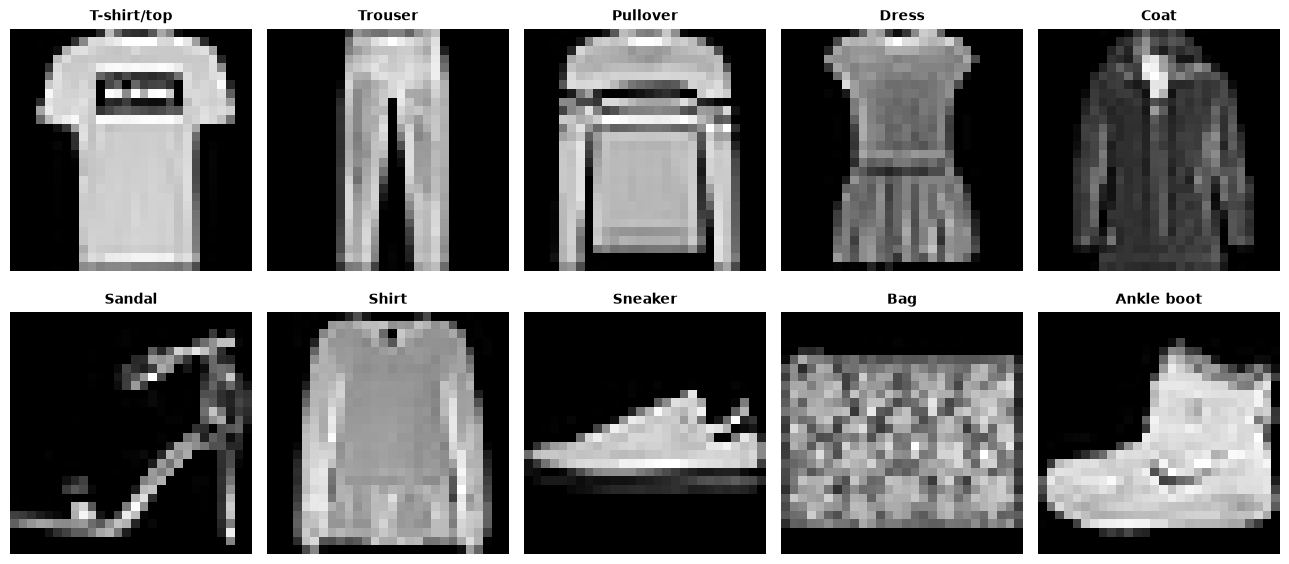

In [68]:
import matplotlib.pyplot as plt

# Recorremos el dataset hasta encontrar un ejemplo representativo por clase.
# No buscamos la "mejor" imagen: solo una muestra rápida para inspección visual.
def get_one_per_class(dataset, n_classes=10):
    found = {}
    for img, label in dataset:
        if label not in found:
            found[label] = img
        if len(found) == n_classes:
            break
    return [found[i] for i in range(n_classes)]

samples = get_one_per_class(train_full)

fig1, axes = plt.subplots(2, 5, figsize=(13, 6))

for ax, img, name in zip(axes.flat, samples, CLASS_NAMES):
    # Desnormalizar para mostrar [-1,1] -> [0,1]
    img_np = img.squeeze().numpy()
    img_np = (img_np * 0.5) + 0.5
    ax.imshow(img_np, cmap='gray')
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

### Distribucion de clases

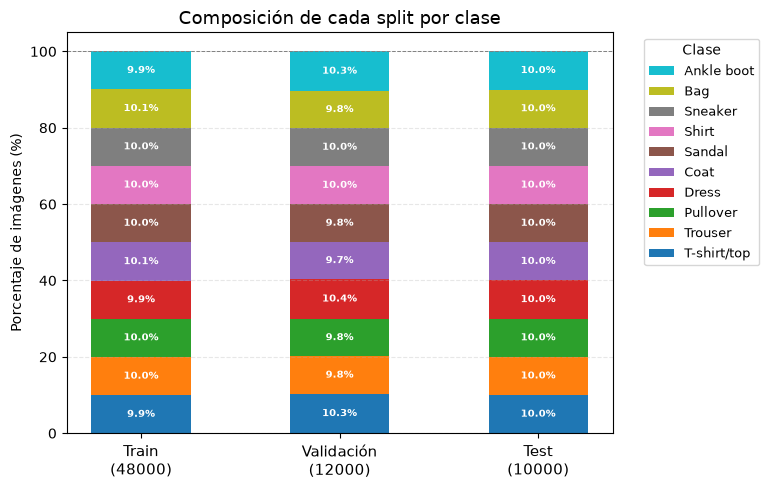

In [69]:
from collections import Counter
import numpy as np

# `random_split` devuelve un `Subset`; este helper unifica cómo leer etiquetas
# tanto de un `Subset` como del dataset original completo.
def get_labels(subset):
    if hasattr(subset, 'dataset'):
        return [subset.dataset.targets[i].item() for i in subset.indices]
    else:
        return subset.targets.tolist()

train_labels = get_labels(train_set)
val_labels   = get_labels(val_set)
test_labels  = get_labels(test_set)

def label_counts(labels):
    c = Counter(labels)
    return [c[i] for i in range(10)]

splits = {
    f'Train\n({train_size})': label_counts(train_labels),
    f'Validación\n({val_size})': label_counts(val_labels),
    f'Test\n({len(test_set)})': label_counts(test_labels),
}

# Pasamos de conteos absolutos a porcentajes para verificar si los splits quedaron balanceados.
splits_pct = {
    name: np.array(counts) / sum(counts) * 100
    for name, counts in splits.items()
}

fig2, ax = plt.subplots(figsize=(8, 5))
bottom = np.zeros(3)
x = np.arange(3)

for i, class_name in enumerate(CLASS_NAMES):
    values = np.array([splits_pct[split][i] for split in splits_pct])
    bars = ax.bar(x, values, bottom=bottom, label=class_name, width=0.5)

    for j, (bar, val) in enumerate(zip(bars, values)):
        if val > 1.5:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bottom[j] + val / 2,
                f'{val:.1f}%',
                ha='center', va='center', fontsize=7, color='white', fontweight='bold'
            )
    bottom += values

ax.set_xticks(x)
ax.set_xticklabels(list(splits_pct.keys()), fontsize=11)
ax.set_ylabel("Porcentaje de imágenes (%)")
ax.set_title("Composición de cada split por clase", fontsize=13)
ax.set_ylim(0, 105)
ax.axhline(100, color='gray', linestyle='--', linewidth=0.7)
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[::-1], labels[::-1],
    loc='upper right', bbox_to_anchor=(1.28, 1), fontsize=9, title="Clase"
)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Rango de valores de los pixeles

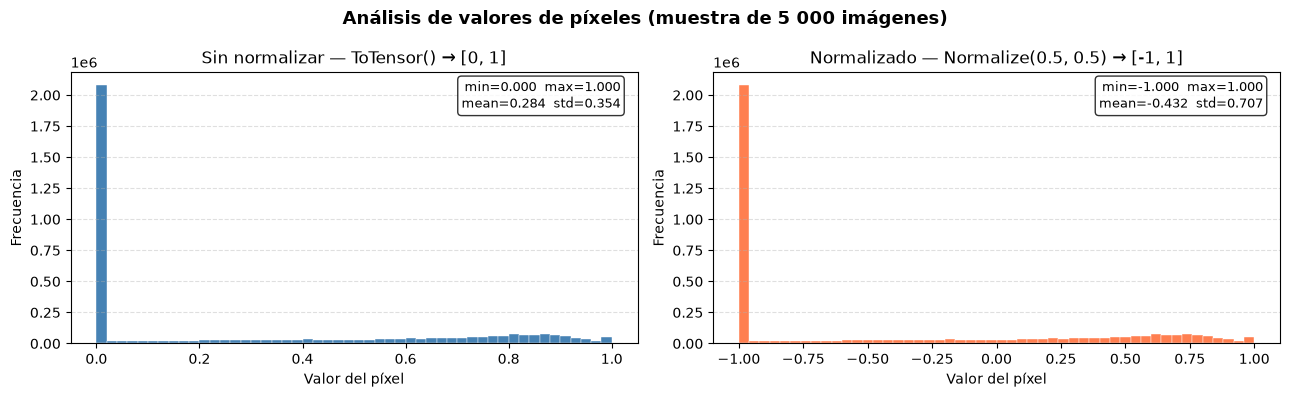

In [70]:
train_counts = label_counts(train_labels)

# calcula stats sobre píxeles RAW (sin normalizar) y normalizados
raw_dataset = datasets.FashionMNIST(
    root='./data', train=True, download=False,
    transform=transforms.ToTensor()
)

# Tomamos una muestra fija para que el análisis exploratorio sea reproducible.
# No hace falta usar las 60k imágenes para ver la forma general de la distribución.
# muestra aleatoria de 5000 imagenes
indices = torch.randperm(len(raw_dataset), generator=torch.Generator().manual_seed(42))[:5000]
sample_pixels_raw = torch.stack([raw_dataset[int(i)][0] for i in indices])
sample_pixels_norm = sample_pixels_raw * 2 - 1

fig3, axes3 = plt.subplots(1, 2, figsize=(13, 4))
fig3.suptitle("Análisis de valores de píxeles (muestra de 5 000 imágenes)", fontsize=13, fontweight='bold')

# histograma
ax = axes3[0]
flat_raw = sample_pixels_raw.flatten().numpy()
ax.hist(flat_raw, bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
ax.set_title("Sin normalizar — ToTensor() → [0, 1]")
ax.set_xlabel("Valor del píxel")
ax.set_ylabel("Frecuencia")
stats_raw = f"min={flat_raw.min():.3f}  max={flat_raw.max():.3f}\nmean={flat_raw.mean():.3f}  std={flat_raw.std():.3f}"
ax.text(0.97, 0.97, stats_raw, transform=ax.transAxes,
        va='top', ha='right', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Este segundo histograma es ilustrativo: muestra cómo se vería una normalización simétrica [-1,1].
# Sirve para explicar el efecto de centrar/escalar, aunque el pipeline principal usa mean/std del dataset.
# histograma normalizado
ax2 = axes3[1]
flat_norm = sample_pixels_norm.flatten().numpy()
ax2.hist(flat_norm, bins=50, color='coral', edgecolor='white', linewidth=0.3)
ax2.set_title("Normalizado — Normalize(0.5, 0.5) → [-1, 1]")
ax2.set_xlabel("Valor del píxel")
ax2.set_ylabel("Frecuencia")
stats_norm = f"min={flat_norm.min():.3f}  max={flat_norm.max():.3f}\nmean={flat_norm.mean():.3f}  std={flat_norm.std():.3f}"
ax2.text(0.97, 0.97, stats_norm, transform=ax2.transAxes,
         va='top', ha='right', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### Forma de las imagenes

In [71]:
shapes = set(raw_dataset[int(i)][0].shape for i in indices)
print(f"Formas únicas en el dataset: {shapes}")

Formas únicas en el dataset: {torch.Size([1, 28, 28])}


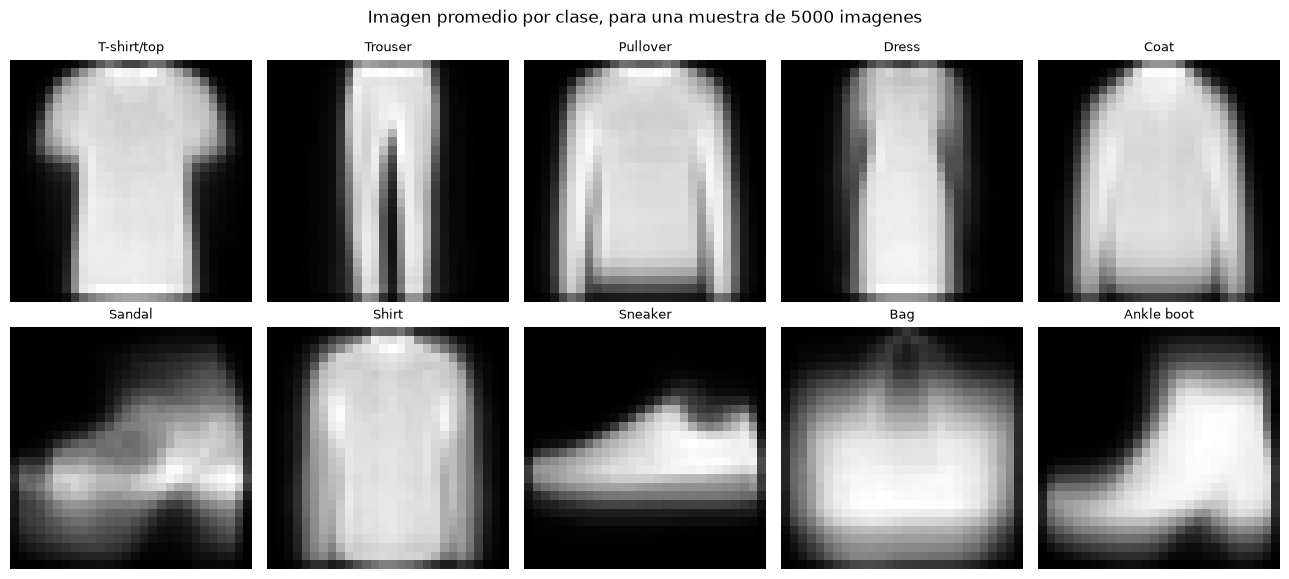

In [72]:
sample_size = min(len(raw_dataset), 5000)

fig, axes = plt.subplots(2, 5, figsize=(13, 6))
fig.suptitle(f"Imagen promedio por clase, para una muestra de {sample_size} imagenes")

for class_idx, ax in enumerate(axes.flat):
    imgs = [raw_dataset[int(i)][0] for i in range(sample_size)
            if raw_dataset[int(i)][1] == class_idx]
    mean_img = torch.stack(imgs).mean(dim=0).squeeze()
    ax.imshow(mean_img, cmap='gray')
    ax.set_title(CLASS_NAMES[class_idx], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

# 3. Preprocesamiento

### Normalizacion de las imagenes
Al inicio de la parte 2, ya se normalizaron las imagenes, para poder hacer correctamente los calculos del analisis, con valores de media y desvio:

In [73]:
print(f"Mean: {mean.item():.4f}") # type: ignore
print(f"Std:  {std.item():.4f}") # type: ignore

Mean: 0.2862
Std:  0.3530


### Aplanado de imagenes

In [74]:
# El MLP no preserva estructura espacial, así que necesita un vector plano de 784 features.
# Reutilizamos la misma normalización que antes y luego aplanamos en el transform.
transform_mlp = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(mean.item(),), std=(std.item(),)),  # type: ignore
    transforms.Lambda(lambda x: x.view(-1))
])

# Cargar datasets
train_full_mlp = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=False,
    transform=transform_mlp
)

test_set_mlp = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=False,
    transform=transform_mlp
)

# Split train/validation
val_size_mlp = int(VALIDATION_SPLIT * len(train_full_mlp))
train_size_mlp = len(train_full_mlp) - val_size_mlp

train_set_mlp, val_set_mlp = random_split(
    train_full_mlp,
    [train_size_mlp, val_size_mlp],
    generator=torch.Generator().manual_seed(42)
)

# DataLoaders
train_loader_mlp = DataLoader(train_set_mlp, batch_size=256, shuffle=True,
                              generator=torch.Generator().manual_seed(42))
val_loader_mlp   = DataLoader(val_set_mlp, batch_size=256, shuffle=False)
test_loader_mlp  = DataLoader(test_set_mlp, batch_size=256, shuffle=False)

print("DataLoaders para MLP creados exitosamente.")
images, labels = next(iter(train_loader_mlp))
print(images.shape)

DataLoaders para MLP creados exitosamente.
torch.Size([256, 784])


# 4. Definición de los Modelos

## Modelo 1: MLP (MultiLayer Feedforward)

In [75]:
import torch
import torch.nn as nn
import torch.optim as optim

# Este MLP se arma dinámicamente a partir de una lista de capas ocultas.
# Eso permite reutilizar el mismo bloque para probar arquitecturas de distinta profundidad/ancho.
class FlexibleMLP(nn.Module):
    def __init__(self, input_size, hidden_layers, output_size, activation, dropout):
        super().__init__()

        # Vamos acumulando bloques lineal -> activación -> dropout por cada capa oculta.
        layers = []
        previous_size = input_size

        for hidden_size in hidden_layers:
            layers.append(nn.Linear(previous_size, hidden_size))
            layers.append(activation())
            layers.append(nn.Dropout(dropout))
            previous_size = hidden_size

        # La última capa entrega logits; no ponemos softmax porque `CrossEntropyLoss` lo aplica internamente.
        layers.append(nn.Linear(previous_size, output_size))

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

In [76]:
# Helper de evaluación: devuelve etiquetas reales y predichas listas para métricas/matriz de confusión.
def get_predictions(model, loader, device):
    model.eval()

    all_preds = []
    all_labels = []

    # `no_grad` evita guardar grafo y reduce memoria/tiempo durante inferencia.
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            # Elegimos la clase con mayor logit; no hace falta softmax para el argmax.
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds

In [77]:
# Factory mínima de optimizadores para desacoplar la arquitectura del algoritmo de entrenamiento.
def get_optimizer(name, model, lr):
    if name == "Adam":
        return optim.Adam(model.parameters(), lr=lr)

    elif name == "SGD":
        return optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    elif name == "RMSprop":
        return optim.RMSprop(model.parameters(), lr=lr)

    else:
        raise ValueError(f"Optimizador no soportado: {name}")

In [78]:
# Loop clásico de entrenamiento/validación para los experimentos iniciales de MLP.
# Guarda historia por época para luego graficar convergencia y comparar estabilidad.
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    num_epochs
):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    # Cada época recorre todo train y luego valida en un conjunto separado no usado para actualizar pesos.
    for epoch in range(num_epochs):
        model.train()

        train_loss = 0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            # Multiplicamos por tamaño de batch para promediar correctamente aunque el último lote sea más chico.
            train_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, dim=1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

        avg_train_loss = train_loss / train_total
        train_acc = train_correct / train_total

        model.eval()

        val_loss = 0
        val_correct = 0
        val_total = 0

        # En validación solo medimos; no hay backward ni actualización de parámetros.
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)

                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        avg_val_loss = val_loss / val_total
        val_acc = val_correct / val_total

        history["train_loss"].append(avg_train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(avg_val_loss)
        history["val_acc"].append(val_acc)

    return history

In [79]:
experiments = [
    {
        "name": "MLP_256_128_ReLU_Adam",
        "hidden_layers": [256, 128],
        "activation": nn.ReLU,
        "dropout": 0.3,
        "optimizer": "Adam",
        "lr": 0.001,
        "epochs": 15
    },
    {
        "name": "MLP_512_256_128_ReLU_Adam",
        "hidden_layers": [512, 256, 128],
        "activation": nn.ReLU,
        "dropout": 0.3,
        "optimizer": "Adam",
        "lr": 0.001,
        "epochs": 15
    },
    {
        "name": "MLP_256_128_LeakyReLU_Adam",
        "hidden_layers": [256, 128],
        "activation": nn.LeakyReLU,
        "dropout": 0.3,
        "optimizer": "Adam",
        "lr": 0.001,
        "epochs": 15
    },
    {
        "name": "MLP_256_128_GELU_Adam",
        "hidden_layers": [256, 128],
        "activation": nn.GELU,
        "dropout": 0.3,
        "optimizer": "Adam",
        "lr": 0.001,
        "epochs": 15
    },
    {
        "name": "MLP_512_256_ReLU_RMSprop",
        "hidden_layers": [512, 256],
        "activation": nn.ReLU,
        "dropout": 0.2,
        "optimizer": "RMSprop",
        "lr": 0.0005,
        "epochs": 15
    }
]

## Modelo 2: CNN (Convolucional)

### Arquitectura CNN Base

In [80]:
import torch
from torch import optim
from torch import nn
from tqdm import tqdm
from dataclasses import dataclass, field
from typing import Literal

# import torchvision

import torch.nn.functional as F
# import torchvision.datasets as datasets
# import torchvision.transforms as transforms

############################
# configuración declarativa de la CNN
############################
# Cada dataclass deja explícitos los hiperparámetros estructurales que después se tunean.
@dataclass
class ConvLayerConfig:
    out_channels: int
    kernel_size: int = 3
    padding: int = 1
    activation: Literal["relu", "tanh", "leaky_relu", "elu", "none"] = "relu"
    pooling: Literal["max", "avg", "none"] = "max"
    use_batchnorm: bool = False
    dropout_p: float = 0.0

@dataclass
class LinearLayerConfig:
    out_features: int
    activation: Literal["relu", "tanh", "leaky_relu", "elu", "none"] = "relu"
    dropout_p: float = 0.0

@dataclass
class TrainConfig:
    num_epochs:   int   = 10
    lr:           float = 0.001
    weight_decay: float = 0.0   # L2 — 0.0 = desactivado
    l1_lambda:    float = 0.0   # L1 — 0.0 = desactivado
    patience:     int   = 0     # early stopping — 0 = desactivado


##################
# helpers
##################
ACTIVATIONS = {
    "relu":       nn.ReLU(),
    "tanh":       nn.Tanh(),
    "leaky_relu": nn.LeakyReLU(),
    "elu":        nn.ELU(),
    "none":       nn.Identity(),
}

POOLING = {
    "max": nn.MaxPool2d(kernel_size=2, stride=2),
    "avg": nn.AvgPool2d(kernel_size=2, stride=2),
    "none": nn.Identity(),
}


######################
# modelo
######################
# La CNN también se construye dinámicamente para poder variar cantidad de filtros,
# activaciones, pooling y capas fully-connected sin reescribir el modelo.
class CNN(nn.Module):
    def __init__(
        self, 
        in_channels: int, 
        input_size: int, # ancho, alto de la img
        num_classes: int,
        conv_layers: list[ConvLayerConfig],
        linear_layers: list[LinearLayerConfig],
        ):
       
        super().__init__()

        conv_blocks = []
        current_channels = in_channels

        # Cada bloque convolucional puede incluir batchnorm, activación, pooling y dropout.
        for cfg in conv_layers:
            conv_blocks += [
                nn.Conv2d(current_channels, cfg.out_channels,
                          kernel_size=cfg.kernel_size, padding=cfg.padding),
                nn.BatchNorm2d(cfg.out_channels) if cfg.use_batchnorm else nn.Identity(),
                ACTIVATIONS[cfg.activation],
                POOLING[cfg.pooling],
                nn.Dropout2d(cfg.dropout_p) if cfg.dropout_p > 0 else nn.Identity(),
            ]
            current_channels = cfg.out_channels
            # Si hay pooling 2x2, la resolución espacial se reduce a la mitad.
            if cfg.pooling != "none":
                input_size //= 2

        self.conv_net = nn.Sequential(*conv_blocks)

        # Este tamaño define cuántas features salen de la parte convolucional hacia el clasificador.
        flatten_size = current_channels * input_size * input_size
        linear_blocks = []
        current_features = flatten_size

        for cfg in linear_layers:
            linear_blocks += [
                nn.Linear(current_features, cfg.out_features),
                ACTIVATIONS[cfg.activation],
                nn.Dropout(cfg.dropout_p) if cfg.dropout_p > 0 else nn.Identity(),
            ]
            current_features = cfg.out_features

        linear_blocks.append(nn.Linear(current_features, num_classes))
        self.linear_net = nn.Sequential(*linear_blocks)


    def forward(self, x):
        x = self.conv_net(x)
        x = x.reshape(x.shape[0], -1)
        x = self.linear_net(x)
        return x


### Función de entrenamiento y evaluación

In [81]:
# Entrenamiento simple de la CNN usado en la sección preliminar.
# A diferencia del pipeline final, acá no hay CV ni cache: es un loop directo para experimentar.
def train(
    model: CNN,
    train_loader,
    cfg: TrainConfig,
    device: str = "cuda" if torch.cuda.is_available() else "cpu",
):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    # El `weight_decay` implementa regularización L2 dentro del optimizador.
    optimizer = optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    history = {"train_loss": []}

    for epoch in range(cfg.num_epochs):
        model.train()
        train_loss = 0.0

        for data, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{cfg.num_epochs}"):
            data, targets = data.to(device), targets.to(device)

            optimizer.zero_grad()
            scores = model(data)
            loss   = criterion(scores, targets)

            # La regularización L1 se suma manualmente a la loss porque no todos los optimizadores la exponen igual.
            if cfg.l1_lambda > 0:
                l1_norm = sum(p.abs().sum() for p in model.parameters())
                loss    = loss + cfg.l1_lambda * l1_norm

            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)
        history["train_loss"].append(train_loss)
        print(f"  train_loss: {train_loss:.4f}")

    return model, history

# 5. Experimentación

## 5.1 Metodología de evaluación

Buscamos el **mejor MLP** y la **mejor CNN** para FashionMNIST y luego los comparamos.

**Validación — k-fold cross validation estratificada (k=5).**
El train está perfectamente balanceado (6.000 imágenes por clase), así que un k-fold simple
ya sería válido; usamos la versión **estratificada** porque garantiza la misma proporción de
clases en cada fold sin costo extra y hace la estimación más robusta frente a una partición
aleatoria desafortunada (el riesgo que marcaba el README). Reportamos la **media ± desvío**
entre folds.

**Early stopping.** Dentro de cada fold reservamos un pequeño split interno (15 %) del train
del fold para monitorear la *loss* de validación. Si no mejora durante `PATIENCE` épocas,
cortamos y restauramos los mejores pesos. El set de evaluación del fold **no** se usa para
parar (no hay fuga). `num_epochs` pasa a ser un *tope máximo* de épocas.

**Métricas** (todas *macro*, las 10 clases pesan igual):
`accuracy`, `precision`, `recall`, `f1-score`, **ROC-AUC** (one-vs-rest) y **matriz de
confusión** agregada sobre todos los folds.

**Cache / guardado de modelos.** Para no reentrenar en cada ejecución:
- Los resultados de CV se cachean en `models/cv_cache/<nombre>.pkl`.
- Los modelos finales se guardan como `models/<nombre>_final.pth` y se cargan si existen.
- El cache se indexa por **nombre**: si cambiás la configuración, **cambiá también el nombre**
  (o poné `FORCE_RECOMPUTE = True`) para que recalcule.

**Proceso de selección**
1. **Ronda 1:** 3 configuraciones por arquitectura → elegimos la mejor por `f1_mean`.
2. **Tuning incremental:** cambiamos **un hiperparámetro a la vez** y re-evaluamos con CV.
3. **Evaluación final:** reentrenamos el mejor de cada arquitectura sobre **todo** el train y
   lo medimos en `test_set` (held-out, nunca usado en la selección).

### Harness de cross-validation (compartido por MLP y CNN)

In [82]:
import os, re, copy, pickle, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve, auc)
from sklearn.preprocessing import label_binarize
import seaborn as sns
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# --- Reproducibilidad ------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


Device: cpu


In [83]:
# === Precarga del dataset en GPU (clave de rendimiento) =============================
# Los modelos son chicos: el cuello de botella era preparar cada batch en CPU (PIL + transform).
# Materializamos TODO el dataset como tensores residentes en GPU una sola vez y batcheamos
# indexando -> sin DataLoader, sin transform por batch, sin copias host->device en cada paso.

def _to_gpu_tensors(ds):
    loader = DataLoader(ds, batch_size=4096, shuffle=False, num_workers=4)
    xs, ys = zip(*[(xb, yb) for xb, yb in loader])
    return torch.cat(xs).to(device), torch.cat(ys).to(device)

X_train_gpu, Y_train_gpu = _to_gpu_tensors(train_full)
X_test_gpu,  Y_test_gpu  = _to_gpu_tensors(test_set)
print(f"Train en GPU: {tuple(X_train_gpu.shape)} {X_train_gpu.dtype} @ {X_train_gpu.device} "
      f"({X_train_gpu.element_size() * X_train_gpu.nelement() / 1e6:.0f} MB)")
print(f"Test  en GPU: {tuple(X_test_gpu.shape)}")


Train en GPU: (60000, 1, 28, 28) torch.float32 @ cpu (188 MB)
Test  en GPU: (10000, 1, 28, 28)


In [84]:
def make_loader(dataset, batch_size, shuffle):
    """DataLoader con kwargs de rendimiento (workers en paralelo + pinned memory)."""
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle,
                      num_workers=4, pin_memory=torch.cuda.is_available(),
                      persistent_workers=True)

class GPULoader:
    """Itera (xb, yb) ya en GPU indexando tensores residentes. Reemplazo directo del DataLoader
    para datasets que entran en memoria de GPU: elimina el overhead de CPU/transfer por batch."""
    def __init__(self, X, Y, indices=None, batch_size=512, shuffle=False):
        self.X, self.Y = X, Y
        self.idx = (torch.arange(X.shape[0], device=X.device) if indices is None
                    else torch.as_tensor(indices, dtype=torch.long, device=X.device))
        self.batch_size, self.shuffle = batch_size, shuffle
    def __iter__(self):
        idx = self.idx
        # El shuffle se hace sobre índices ya residentes en GPU para evitar costo extra en CPU.
        if self.shuffle:
            idx = idx[torch.randperm(idx.numel(), device=idx.device)]
        for i in range(0, idx.numel(), self.batch_size):
            b = idx[i:i + self.batch_size]
            yield self.X[b], self.Y[b]
    def __len__(self):
        return (self.idx.numel() + self.batch_size - 1) // self.batch_size

# Dataset base normalizado (imágenes [1,28,28]) y etiquetas para estratificar.
# train_full se definió en la celda de carga (sección 2).
cv_dataset = train_full
cv_labels  = np.array(train_full.targets)

N_SPLITS        = 5
SEED            = 42
PATIENCE        = 3      # early stopping: épocas sin mejora antes de cortar (0 = desactivado)
INNER_VAL_FRAC  = 0.15   # porción de cada fold reservada para monitorear early stopping
FORCE_RECOMPUTE = False  # True = ignora cache y recalcula / reentrena todo

CV_CACHE_DIR = "models/cv_cache"
FINAL_DIR    = "models"
os.makedirs(CV_CACHE_DIR, exist_ok=True)
os.makedirs(FINAL_DIR, exist_ok=True)


def _slug(name):
    return re.sub(r"[^A-Za-z0-9._-]+", "_", name).strip("_")


# --- MLP que acepta imágenes [B,1,28,28] (aplana adentro) para usar el mismo loop que la CNN ---
# Wrapper para que el MLP reciba imágenes con la misma forma que la CNN.
# El aplanado ocurre adentro y así el resto del pipeline no necesita casos especiales.
class MLPForCV(nn.Module):
    def __init__(self, hidden_layers, activation, dropout):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = FlexibleMLP(784, hidden_layers, 10, activation, dropout)
    def forward(self, x):
        return self.net(self.flatten(x))


def build_cnn(conv_layers, linear_layers):
    """Atajo para crear una CNN con la firma fija de FashionMNIST."""
    return CNN(in_channels=1, input_size=28, num_classes=10,
               conv_layers=conv_layers, linear_layers=linear_layers)


@torch.no_grad()
def _val_loss(model, loader, criterion):
    model.eval()
    total, n = 0.0, 0
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        total += criterion(model(x), y).item() * x.size(0)
        n += x.size(0)
    return total / n


def _fit(model, train_loader, val_loader, criterion, optimizer,
         max_epochs, l1_lambda=0.0, patience=PATIENCE):
    """Entrena con early stopping (si patience>0 y hay val_loader) y restaura los mejores pesos."""
    # Guardamos el mejor estado según validation loss para restaurarlo al final.
    best_loss, best_state, no_improve = float("inf"), None, 0
    for _ in range(max_epochs):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            if l1_lambda > 0:
                loss = loss + l1_lambda * sum(p.abs().sum() for p in model.parameters())
            loss.backward()
            optimizer.step()
        # El early stopping se decide sobre un split interno de train, no sobre el fold de evaluación.
        if patience > 0 and val_loader is not None:
            vloss = _val_loss(model, val_loader, criterion)
            if vloss < best_loss - 1e-4:
                best_loss, best_state, no_improve = vloss, copy.deepcopy(model.state_dict()), 0
            else:
                no_improve += 1
                if no_improve >= patience:
                    break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model


@torch.no_grad()
def _predict(model, loader):
    """Devuelve (y_true, y_pred, y_proba) — y_proba son probabilidades softmax para ROC."""
    model.eval()
    probas, trues = [], []
    for x, y in loader:
        probas.append(torch.softmax(model(x.to(device, non_blocking=True)), dim=1).cpu())
        trues.extend(y.tolist())
    probas = torch.cat(probas).numpy()
    return np.array(trues), probas.argmax(1), probas


def _metrics(y_true, y_pred, y_proba):
    return {
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall":    recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1":        f1_score(y_true, y_pred, average="macro", zero_division=0),
        "roc_auc":   roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro"),
    }


# Núcleo del benchmarking: evalúa una configuración con CV estratificada y cachea resultados.
# Así evitamos volver a entrenar configuraciones ya corridas al iterar sobre el notebook.
def cross_validate(name, model_fn, build_optimizer, num_epochs,
                   n_splits=N_SPLITS, l1_lambda=0.0, patience=PATIENCE,
                   batch_size=512, verbose=True) -> tuple:
    """
    Evalúa UNA configuración con StratifiedKFold + early stopping. Cachea el resultado.

    model_fn        : función sin args que devuelve un modelo nuevo (lambda: MLPForCV(...))
    build_optimizer : función modelo -> optimizador (permite lr, weight_decay, etc.)
    Devuelve (summary dict, df por fold, matriz de confusión agregada).
    """
    cache_path = os.path.join(CV_CACHE_DIR, _slug(name) + ".pkl")
    # La caché guarda resumen, métricas por fold y matriz agregada para acelerar reruns.
    if not FORCE_RECOMPUTE and os.path.exists(cache_path):
        with open(cache_path, "rb") as f:
            summary, df, cm = pickle.load(f)
        if verbose:
            print(f"  [{name}] cargado de cache  "
                  f"(acc={summary['acc_mean']:.4f}  f1={summary['f1_mean']:.4f}  roc={summary['roc_mean']:.4f})")
        return summary, df, cm

    # Estratificamos para que cada fold conserve proporciones de clase similares al dataset original.
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    criterion = nn.CrossEntropyLoss()
    rows, cm_total = [], np.zeros((10, 10), dtype=int)

    for fold, (tr, va) in enumerate(skf.split(cv_labels, cv_labels), 1):
        torch.manual_seed(SEED)                       # init reproducible entre configs
        model = model_fn().to(device)
        optimizer = build_optimizer(model)

        # split interno para early stopping (no toca el set de evaluación del fold)
        # Reservamos una fracción del train del fold para early stopping sin tocar el fold de validación externa.
        if patience > 0:
            inner_tr, inner_va = train_test_split(
                tr, test_size=INNER_VAL_FRAC, random_state=SEED, stratify=cv_labels[tr])
            train_loader = GPULoader(X_train_gpu, Y_train_gpu, inner_tr, batch_size, True)
            es_loader    = GPULoader(X_train_gpu, Y_train_gpu, inner_va, batch_size, False)
        else:
            train_loader = GPULoader(X_train_gpu, Y_train_gpu, tr, batch_size, True)
            es_loader    = None

        val_loader = GPULoader(X_train_gpu, Y_train_gpu, va, batch_size, False)

        _fit(model, train_loader, es_loader, criterion, optimizer, num_epochs, l1_lambda, patience)
        y_true, y_pred, y_proba = _predict(model, val_loader)

        m = _metrics(y_true, y_pred, y_proba)
        m["fold"] = fold
        rows.append(m)
        cm_total += confusion_matrix(y_true, y_pred, labels=list(range(10)))
        if verbose:
            print(f"  [{name}] fold {fold}/{n_splits}  acc={m['accuracy']:.4f}  "
                  f"f1={m['f1']:.4f}  roc={m['roc_auc']:.4f}")

    df = pd.DataFrame(rows)
    summary = {
        "model":     name,
        "acc_mean":  df["accuracy"].mean(),  "acc_std": df["accuracy"].std(),
        "prec_mean": df["precision"].mean(),
        "rec_mean":  df["recall"].mean(),
        "f1_mean":   df["f1"].mean(),        "f1_std":  df["f1"].std(),
        "roc_mean":  df["roc_auc"].mean(),
    }
    with open(cache_path, "wb") as f:
        pickle.dump((summary, df, cm_total), f)
    return summary, df, cm_total


def run_round(configs) -> tuple:
    """Corre cross_validate sobre una lista de configs y devuelve (tabla ordenada, dict de CMs)."""
    summaries, cms = [], {}
    for cfg in configs:
        print(f"\n=== {cfg['name']} ===")
        s, _, cm = cross_validate(**cfg)
        summaries.append(s)
        cms[cfg["name"]] = cm
    table = (pd.DataFrame(summaries)
             .sort_values("f1_mean", ascending=False)
             .reset_index(drop=True))
    return table, cms


def plot_cm(cm, title):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(title)
    plt.xlabel("Predicho"); plt.ylabel("Real")
    plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
    plt.tight_layout(); plt.show()


def plot_roc(y_true, y_proba, title):
    """Curvas ROC one-vs-rest, una por clase, con su AUC."""
    y_bin = np.asarray(label_binarize(y_true, classes=list(range(10))))
    plt.figure(figsize=(8, 6))
    for i in range(10):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
        plt.plot(fpr, tpr, lw=1.2, label=f"{CLASS_NAMES[i]} (AUC={auc(fpr, tpr):.3f})")
    plt.plot([0, 1], [0, 1], "k--", lw=1)
    plt.xlabel("Tasa de falsos positivos"); plt.ylabel("Tasa de verdaderos positivos")
    plt.title(title); plt.legend(fontsize=8, loc="lower right")
    plt.tight_layout(); plt.show()

/tmp/ipykernel_20698/151214885.py:28: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  cv_labels  = np.array(train_full.targets)


In [85]:
# === Helpers de ronda: guardar métricas + reentrenar y guardar la mejor config ======
# Flujo por ronda:
#   1) CV sobre las N configs (run_round) -> métricas promedio de los 5 folds.
#   2) Se guarda la tabla de métricas (CSV por ronda + leaderboard acumulado) para el informe.
#   3) Se elige la mejor por f1_mean, se REENTRENA sobre TODO el train y se guardan sus pesos.
# Importante: la comparación ENTRE rondas se hace con las métricas de CV (f1_mean),
# NO sobre el test. El test held-out se usa una sola vez al final (evaluate_on_test).

METRICS_DIR = "models/metrics"
os.makedirs(METRICS_DIR, exist_ok=True)
LEADERBOARD = []   # acumula las tablas de todas las rondas corridas en la sesión


# Una vez que una configuración gana una ronda, la reentrenamos con todo el train
# para guardar pesos reutilizables antes de pasar a la siguiente etapa.
def fit_full_and_save(name, model_fn, build_optimizer, num_epochs,
                      l1_lambda=0.0, patience=PATIENCE, batch_size=512, force=False):
    """Reentrena la config sobre TODO el train (con early stopping) y guarda los pesos
    en models/<name>.pth. Si ya existe, lo carga y no reentrena. No toca el test."""
    path = os.path.join(FINAL_DIR, f"{_slug(name)}.pth")
    torch.manual_seed(SEED)
    model = model_fn().to(device)
    if not force and not FORCE_RECOMPUTE and os.path.exists(path):
        model.load_state_dict(torch.load(path, map_location=device))
        print(f"  modelo cargado desde {path} (no se reentrena)")
        return model

    criterion = nn.CrossEntropyLoss()
    optimizer = build_optimizer(model)
    idx = np.arange(len(train_full))
    if patience > 0:
        tr_idx, va_idx = train_test_split(
            idx, test_size=INNER_VAL_FRAC, random_state=SEED, stratify=cv_labels)
        train_loader = GPULoader(X_train_gpu, Y_train_gpu, tr_idx, batch_size, True)
        es_loader    = GPULoader(X_train_gpu, Y_train_gpu, va_idx, batch_size, False)
    else:
        train_loader = GPULoader(X_train_gpu, Y_train_gpu, None, batch_size, True)
        es_loader    = None
    _fit(model, train_loader, es_loader, criterion, optimizer, num_epochs, l1_lambda, patience)
    torch.save(model.state_dict(), path)
    print(f"  modelo guardado en {path}")
    return model


# Ejecuta una ronda completa, persiste métricas y deja identificado un ganador.
# Ese ganador es el punto de partida de la siguiente ronda del tuning secuencial.
def run_and_save_round(round_name, configs):
    """Corre la ronda completa, guarda métricas y reentrena/guarda la mejor config.
    Devuelve (tabla, cms, best_name, best_model)."""
    table, cms = run_round(configs)
    table.insert(0, "round", round_name)

    # 2) métricas a disco (CSV por ronda + leaderboard acumulado)
    csv_path = os.path.join(METRICS_DIR, f"{_slug(round_name)}.csv")
    table.to_csv(csv_path, index=False)
    LEADERBOARD.append(table)
    pd.concat(LEADERBOARD, ignore_index=True).to_csv(
        os.path.join(METRICS_DIR, "leaderboard.csv"), index=False)
    print(f"\nMétricas de '{round_name}' guardadas en {csv_path}")
    display(table)

    # 3) reentrenar y guardar la mejor de la ronda (para comparar con las próximas)
    best_name = table.iloc[0]["model"]
    cfg = next(c for c in configs if c["name"] == best_name)
    print(f"\nMejor de '{round_name}': {best_name}  (f1={table.iloc[0]['f1_mean']:.4f})"
          f"\nReentrenando sobre todo el train y guardando...")
    best_model = fit_full_and_save(
        f"best_{_slug(round_name)}",
        cfg["model_fn"], cfg["build_optimizer"], cfg["num_epochs"],
        l1_lambda=cfg.get("l1_lambda", 0.0), patience=cfg.get("patience", PATIENCE))
    plot_cm(cms[best_name], f"{round_name} — mejor: {best_name}")
    return table, cms, best_name, best_model

### 5.2 MLP — Ronda 1 (3 configuraciones)

Tres puntos de partida bien distintos: red base, red más profunda/ancha, y una variante
con activación GELU + weight decay.


=== MLP-A  [256,128] ReLU drop0.3 Adam ===
  [MLP-A  [256,128] ReLU drop0.3 Adam] cargado de cache  (acc=0.8909  f1=0.8903  roc=0.9922)

=== MLP-B  [512,256,128] ReLU drop0.3 Adam ===
  [MLP-B  [512,256,128] ReLU drop0.3 Adam] cargado de cache  (acc=0.8917  f1=0.8911  roc=0.9921)

=== MLP-C  [512,256] GELU drop0.2 Adam+wd ===
  [MLP-C  [512,256] GELU drop0.2 Adam+wd] cargado de cache  (acc=0.8938  f1=0.8932  roc=0.9926)

Métricas de 'MLP ronda 1' guardadas en models/metrics/MLP_ronda_1.csv


,round,model,acc_mean,acc_std,prec_mean,rec_mean,f1_mean,f1_std,roc_mean
0,MLP ronda 1,"MLP-C [512,256] GELU drop0.2 Adam+wd",0.893783,0.002733,0.894119,0.893783,0.893159,0.002688,0.992567
1,MLP ronda 1,"MLP-B [512,256,128] ReLU drop0.3 Adam",0.891683,0.002877,0.891681,0.891683,0.891114,0.002901,0.992107
2,MLP ronda 1,"MLP-A [256,128] ReLU drop0.3 Adam",0.890917,0.003717,0.891042,0.890917,0.890300,0.003865,0.992193



Mejor de 'MLP ronda 1': MLP-C  [512,256] GELU drop0.2 Adam+wd  (f1=0.8932)
Reentrenando sobre todo el train y guardando...
  modelo cargado desde models/best_MLP_ronda_1.pth (no se reentrena)


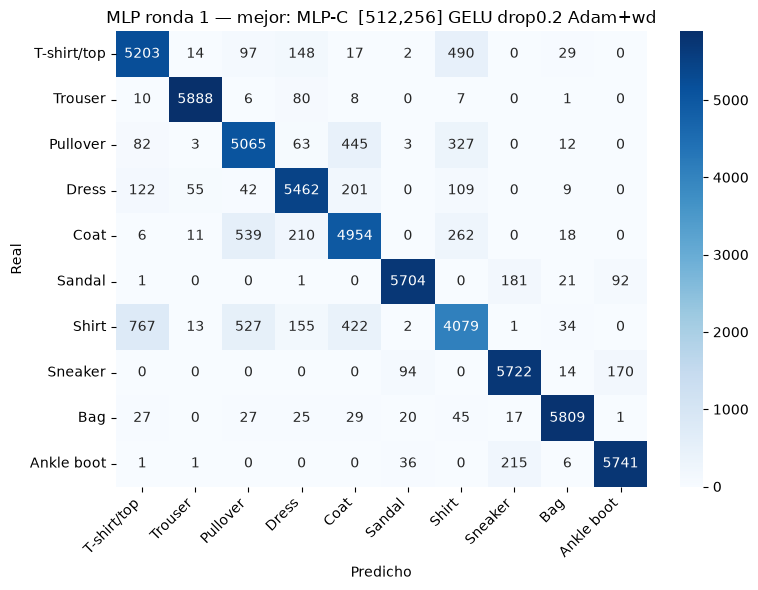

In [86]:
mlp_round1 = [
    dict(name="MLP-A  [256,128] ReLU drop0.3 Adam",
         model_fn=lambda: MLPForCV([256, 128], nn.ReLU, 0.3),
         build_optimizer=lambda m: optim.Adam(m.parameters(), lr=1e-3),
         num_epochs=25),
    dict(name="MLP-B  [512,256,128] ReLU drop0.3 Adam",
         model_fn=lambda: MLPForCV([512, 256, 128], nn.ReLU, 0.3),
         build_optimizer=lambda m: optim.Adam(m.parameters(), lr=1e-3),
         num_epochs=25),
    dict(name="MLP-C  [512,256] GELU drop0.2 Adam+wd",
         model_fn=lambda: MLPForCV([512, 256], nn.GELU, 0.2),
         build_optimizer=lambda m: optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-4),
         num_epochs=25),
]

mlp_table, mlp_cms, mlp_best, mlp_best_model = run_and_save_round("MLP ronda 1", mlp_round1)

### 5.3 CNN — Ronda 1 (3 configuraciones)

Tres arquitecturas: baseline chica, una con BatchNorm + dropout + weight decay, y una con
BatchNorm + LeakyReLU.


=== CNN-A  baseline [8,16]->128 ===
  [CNN-A  baseline [8,16]->128] cargado de cache  (acc=0.8968  f1=0.8961  roc=0.9927)

=== CNN-B  BN [32,64]->256,128 dropout+wd ===
  [CNN-B  BN [32,64]->256,128 dropout+wd] cargado de cache  (acc=0.9230  f1=0.9225  roc=0.9955)

=== CNN-C  BN+LeakyReLU [32,64]->128 ===
  [CNN-C  BN+LeakyReLU [32,64]->128] cargado de cache  (acc=0.9165  f1=0.9164  roc=0.9949)

Métricas de 'CNN ronda 1' guardadas en models/metrics/CNN_ronda_1.csv


,round,model,acc_mean,acc_std,prec_mean,rec_mean,f1_mean,f1_std,roc_mean
0,CNN ronda 1,"CNN-B BN [32,64]->256,128 dropout+wd",0.922967,0.003272,0.922577,0.922967,0.922501,0.003409,0.995509
1,CNN ronda 1,"CNN-C BN+LeakyReLU [32,64]->128",0.916467,0.002191,0.917066,0.916467,0.916382,0.002114,0.994881
2,CNN ronda 1,"CNN-A baseline [8,16]->128",0.896767,0.006986,0.896862,0.896767,0.896085,0.006762,0.992670



Mejor de 'CNN ronda 1': CNN-B  BN [32,64]->256,128 dropout+wd  (f1=0.9225)
Reentrenando sobre todo el train y guardando...
  modelo cargado desde models/best_CNN_ronda_1.pth (no se reentrena)


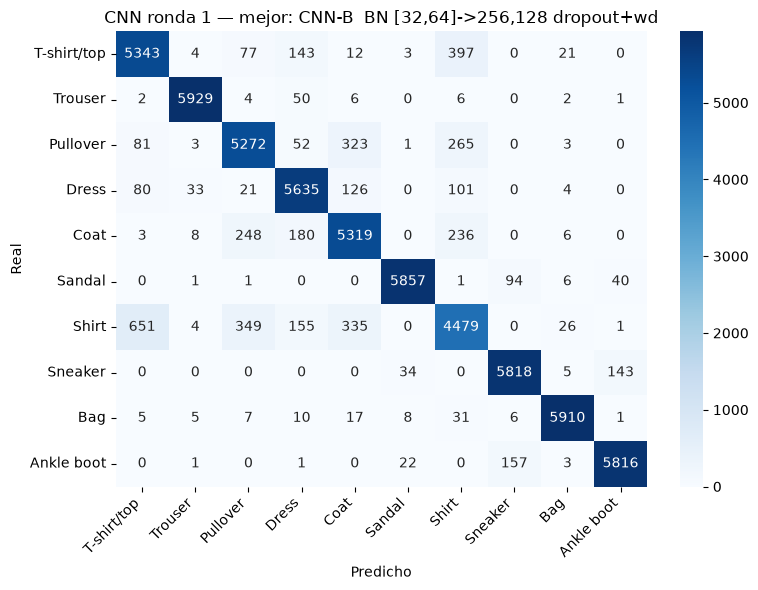

In [87]:
cnn_round1 = [
    dict(name="CNN-A  baseline [8,16]->128",
         model_fn=lambda: build_cnn(
             [ConvLayerConfig(out_channels=8), ConvLayerConfig(out_channels=16)],
             [LinearLayerConfig(out_features=128)]),
         build_optimizer=lambda m: optim.Adam(m.parameters(), lr=1e-3),
         num_epochs=20),
    dict(name="CNN-B  BN [32,64]->256,128 dropout+wd",
         model_fn=lambda: build_cnn(
             [ConvLayerConfig(out_channels=32, use_batchnorm=True),
              ConvLayerConfig(out_channels=64, use_batchnorm=True, dropout_p=0.25)],
             [LinearLayerConfig(out_features=256, dropout_p=0.5),
              LinearLayerConfig(out_features=128, dropout_p=0.25)]),
         build_optimizer=lambda m: optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-4),
         num_epochs=20),
    dict(name="CNN-C  BN+LeakyReLU [32,64]->128",
         model_fn=lambda: build_cnn(
             [ConvLayerConfig(out_channels=32, use_batchnorm=True, activation="leaky_relu"),
              ConvLayerConfig(out_channels=64, use_batchnorm=True)],
             [LinearLayerConfig(out_features=128)]),
         build_optimizer=lambda m: optim.Adam(m.parameters(), lr=1e-3),
         num_epochs=20),
]

cnn_table, cnn_cms, cnn_best, cnn_best_model = run_and_save_round("CNN ronda 1", cnn_round1)

### 5.4 Tuning incremental (paso a paso)

Tomamos el mejor de cada tabla y cambiamos **un hiperparámetro a la vez**, re-evaluando con
CV. Plantilla para una ronda de tuning (editar y correr según lo que queramos probar):

Candidatos a barrer, de a uno:
- **learning rate** (1e-3 → 5e-4, 2e-3)
- **dropout** (0.2 / 0.3 / 0.5)
- **ancho / profundidad** de capas
- **optimizador** (Adam / RMSprop / SGD+momentum)
- **regularización** (`weight_decay` L2, `l1_lambda` L1)
- **BatchNorm** sí/no (CNN)
- **épocas**

Vamos a hacer esto juntos, paso a paso, después de ver los resultados de la Ronda 1.

#### Tuning incremental encadenado (greedy)

Tomamos el ganador de la Ronda 1 y vamos cambiando **un hiperparámetro por ronda**. Clave:
cada ronda parte del **ganador de la ronda anterior**, no siempre de la config original. Así, al
terminar la cadena, `mlp_spec` / `cnn_spec` contienen la **mejor combinación** acumulada, que es
la que se lleva a la evaluación final en test (5.5).

Cada ronda incluye la config base (el ganador previo) como referencia — cae en caché, así que es
gratis — y muestra en la tabla si el cambio **mejora o empeora** el `f1_mean`.

In [88]:
# === Motor de tuning secuencial (greedy / coordinate descent) =======================
# Cada ronda PARTE DEL GANADOR de la ronda anterior y cambia un hiperparámetro.
# Así, al terminar la cadena, queda el modelo con la mejor COMBINACIÓN encontrada.
# La config se representa como un dict de hiperparámetros ("spec"); mlp_config/cnn_config
# lo convierten en (model_fn, build_optimizer). tune() arma base + variantes, corre la
# ronda y devuelve (spec_ganador, nombre_ganador) para encadenar con la ronda siguiente.

def _build_optimizer(spec):
    opt, lr, wd = spec["opt"], spec["lr"], spec["wd"]
    if opt == "adam":    return lambda m: optim.Adam(m.parameters(), lr=lr, weight_decay=wd)
    if opt == "rmsprop": return lambda m: optim.RMSprop(m.parameters(), lr=lr, weight_decay=wd)
    if opt == "sgd":     return lambda m: optim.SGD(m.parameters(), lr=lr, momentum=0.9, weight_decay=wd)
    raise ValueError(f"optimizador desconocido: {opt}")

def mlp_config(name, spec):
    return dict(name=name,
                model_fn=lambda: MLPForCV(spec["hidden"], spec["act"], spec["dropout"]),
                build_optimizer=_build_optimizer(spec),
                num_epochs=spec["epochs"])

def cnn_config(name, spec):
    def build():
        conv = [ConvLayerConfig(out_channels=spec["channels"][0], use_batchnorm=spec["bn"]),
                ConvLayerConfig(out_channels=spec["channels"][1], use_batchnorm=spec["bn"],
                                dropout_p=spec["conv_drop"])]
        lin  = [LinearLayerConfig(out_features=spec["fc"][0], dropout_p=spec["fc_drop"][0]),
                LinearLayerConfig(out_features=spec["fc"][1], dropout_p=spec["fc_drop"][1])]
        return build_cnn(conv, lin)
    return dict(name=name, model_fn=build,
                build_optimizer=_build_optimizer(spec), num_epochs=spec["epochs"])

# `tune` implementa una búsqueda secuencial tipo greedy: cambia un eje por vez.
# No explora toda la grilla posible, pero permite justificar cómo evoluciona el modelo paso a paso.
def tune(round_name, base_spec, base_name, changes, make_config):
    """Ronda secuencial. Parte de (base_spec, base_name) y prueba `changes`:
    lista de (etiqueta, overrides) donde overrides es un dict de hiperparámetros a cambiar
    respecto del ganador previo (normalmente uno solo; el optimizador lleva su lr acoplado).
    Incluye la base (cae en caché) para comparar. Devuelve (spec_ganador, nombre_ganador)."""
    name_to_spec = {base_name: dict(base_spec)}
    configs = [make_config(base_name, dict(base_spec))]
    for label, ov in changes:
        s = dict(base_spec); s.update(ov)
        vname = f"{base_name} + {label}"
        name_to_spec[vname] = s
        configs.append(make_config(vname, s))
    table, cms, best_name, best_model = run_and_save_round(round_name, configs)
    best_spec = name_to_spec[best_name]
    nota = "(sin cambio: ganó la base)" if best_name == base_name else "(cambió el ganador)"
    print(f"\n[{round_name}] -> ganador: {best_name}  {nota}")
    return best_spec, best_name

##### Cadena de tuning — MLP

In [89]:
# Punto de partida MLP: ganador de la Ronda 1 (MLP-C). A partir de acá se encadena.
mlp_spec = dict(hidden=[512, 256], act=nn.GELU, dropout=0.2,
                opt="adam", lr=1e-3, wd=1e-4, epochs=25)
mlp_name = "MLP-C  [512,256] GELU drop0.2 Adam+wd"   # nombre cacheado de la Ronda 1


=== MLP-C  [512,256] GELU drop0.2 Adam+wd ===
  [MLP-C  [512,256] GELU drop0.2 Adam+wd] cargado de cache  (acc=0.8938  f1=0.8932  roc=0.9926)

=== MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4 ===
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4] cargado de cache  (acc=0.8940  f1=0.8936  roc=0.9926)

=== MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=2e-3 ===
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=2e-3] cargado de cache  (acc=0.8905  f1=0.8897  roc=0.9922)

Métricas de 'MLP ronda 2 (lr)' guardadas en models/metrics/MLP_ronda_2_lr.csv


,round,model,acc_mean,acc_std,prec_mean,rec_mean,f1_mean,f1_std,roc_mean
0,MLP ronda 2 (lr),"MLP-C [512,256] GELU drop0.2 Adam+wd + lr=5e-4",0.893950,0.003321,0.894021,0.893950,0.893560,0.003741,0.992625
1,MLP ronda 2 (lr),"MLP-C [512,256] GELU drop0.2 Adam+wd",0.893783,0.002733,0.894119,0.893783,0.893159,0.002688,0.992567
2,MLP ronda 2 (lr),"MLP-C [512,256] GELU drop0.2 Adam+wd + lr=2e-3",0.890500,0.003950,0.890608,0.890500,0.889665,0.004374,0.992236



Mejor de 'MLP ronda 2 (lr)': MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4  (f1=0.8936)
Reentrenando sobre todo el train y guardando...
  modelo cargado desde models/best_MLP_ronda_2_lr.pth (no se reentrena)


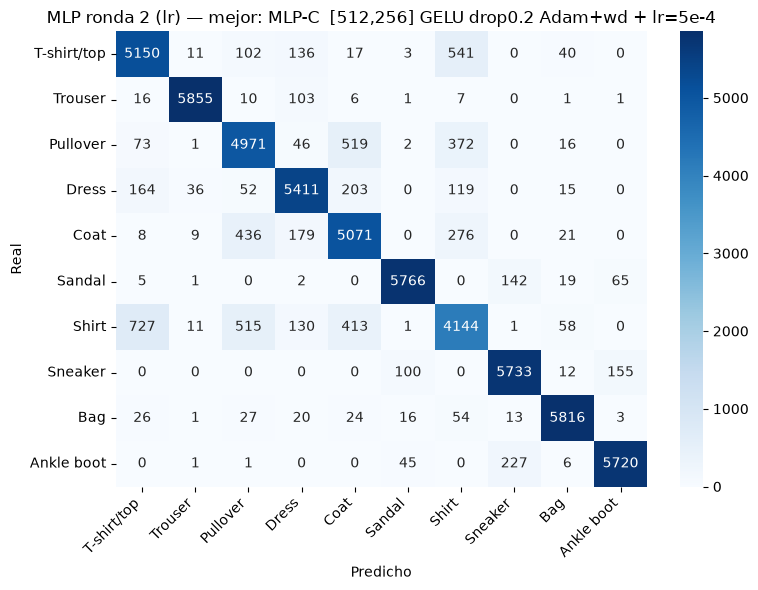


[MLP ronda 2 (lr)] -> ganador: MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4  (cambió el ganador)


In [90]:
# Ronda 2 — learning rate
mlp_spec, mlp_name = tune("MLP ronda 2 (lr)", mlp_spec, mlp_name,
    [("lr=5e-4", {"lr": 5e-4}), ("lr=2e-3", {"lr": 2e-3})], mlp_config)


=== MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4 ===
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4] cargado de cache  (acc=0.8940  f1=0.8936  roc=0.9926)

=== MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4 + drop=0.1 ===
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4 + drop=0.1] cargado de cache  (acc=0.8956  f1=0.8954  roc=0.9927)

=== MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4 + drop=0.3 ===
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4 + drop=0.3] cargado de cache  (acc=0.8963  f1=0.8960  roc=0.9926)

=== MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4 + drop=0.4 ===
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4 + drop=0.4] cargado de cache  (acc=0.8955  f1=0.8952  roc=0.9927)

Métricas de 'MLP ronda 3 (dropout)' guardadas en models/metrics/MLP_ronda_3_dropout.csv


,round,model,acc_mean,acc_std,prec_mean,rec_mean,f1_mean,f1_std,roc_mean
0,MLP ronda 3 (dropout),"MLP-C [512,256] GELU drop0.2 Adam+wd + lr=5e-...",0.896300,0.001147,0.896345,0.896300,0.895983,0.001410,0.992641
1,MLP ronda 3 (dropout),"MLP-C [512,256] GELU drop0.2 Adam+wd + lr=5e-...",0.895583,0.001174,0.895775,0.895583,0.895394,0.000933,0.992692
2,MLP ronda 3 (dropout),"MLP-C [512,256] GELU drop0.2 Adam+wd + lr=5e-...",0.895550,0.002752,0.895695,0.895550,0.895164,0.002634,0.992712
3,MLP ronda 3 (dropout),"MLP-C [512,256] GELU drop0.2 Adam+wd + lr=5e-4",0.893950,0.003321,0.894021,0.893950,0.893560,0.003741,0.992625



Mejor de 'MLP ronda 3 (dropout)': MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4 + drop=0.3  (f1=0.8960)
Reentrenando sobre todo el train y guardando...
  modelo cargado desde models/best_MLP_ronda_3_dropout.pth (no se reentrena)


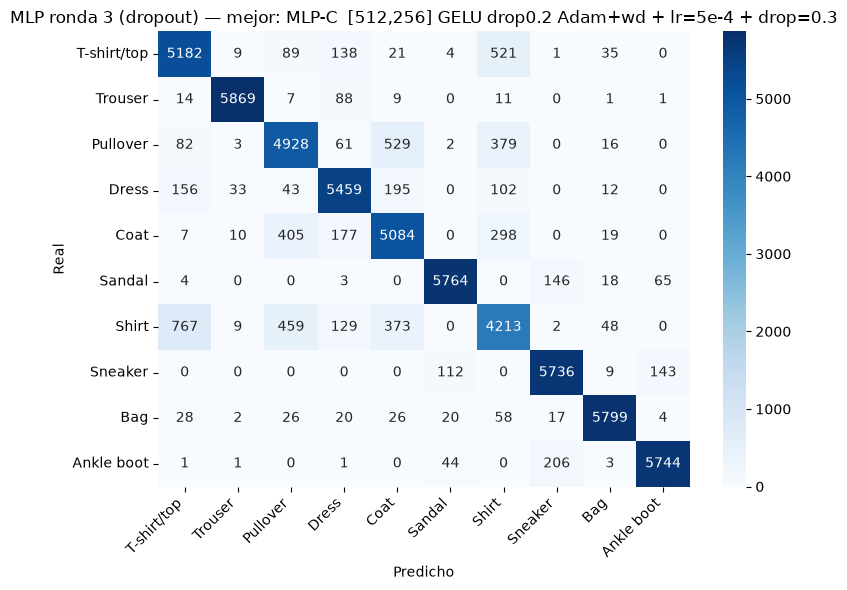


[MLP ronda 3 (dropout)] -> ganador: MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4 + drop=0.3  (cambió el ganador)


In [91]:
# Ronda 3 — dropout
mlp_spec, mlp_name = tune("MLP ronda 3 (dropout)", mlp_spec, mlp_name,
    [("drop=0.1", {"dropout": 0.1}), ("drop=0.3", {"dropout": 0.3}), ("drop=0.4", {"dropout": 0.4})], mlp_config)


=== MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4 + drop=0.3 ===
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4 + drop=0.3] cargado de cache  (acc=0.8963  f1=0.8960  roc=0.9926)

=== MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4 + drop=0.3 + [256,128] ===
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4 + drop=0.3 + [256,128]] cargado de cache  (acc=0.8936  f1=0.8934  roc=0.9925)

=== MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4 + drop=0.3 + [512,256,128] ===
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4 + drop=0.3 + [512,256,128]] cargado de cache  (acc=0.8949  f1=0.8945  roc=0.9926)

=== MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4 + drop=0.3 + [1024,512] ===
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4 + drop=0.3 + [1024,512]] cargado de cache  (acc=0.8936  f1=0.8935  roc=0.9927)

Métricas de 'MLP ronda 4 (capacidad)' guardadas en models/metrics/MLP_ronda_4_capacidad.csv


,round,model,acc_mean,acc_std,prec_mean,rec_mean,f1_mean,f1_std,roc_mean
0,MLP ronda 4 (capacidad),"MLP-C [512,256] GELU drop0.2 Adam+wd + lr=5e-...",0.896300,0.001147,0.896345,0.896300,0.895983,0.001410,0.992641
1,MLP ronda 4 (capacidad),"MLP-C [512,256] GELU drop0.2 Adam+wd + lr=5e-...",0.894900,0.002651,0.895004,0.894900,0.894480,0.002850,0.992614
2,MLP ronda 4 (capacidad),"MLP-C [512,256] GELU drop0.2 Adam+wd + lr=5e-...",0.893617,0.004006,0.894774,0.893617,0.893530,0.003961,0.992662
3,MLP ronda 4 (capacidad),"MLP-C [512,256] GELU drop0.2 Adam+wd + lr=5e-...",0.893567,0.002250,0.893986,0.893567,0.893358,0.002446,0.992532



Mejor de 'MLP ronda 4 (capacidad)': MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4 + drop=0.3  (f1=0.8960)
Reentrenando sobre todo el train y guardando...
  modelo cargado desde models/best_MLP_ronda_4_capacidad.pth (no se reentrena)


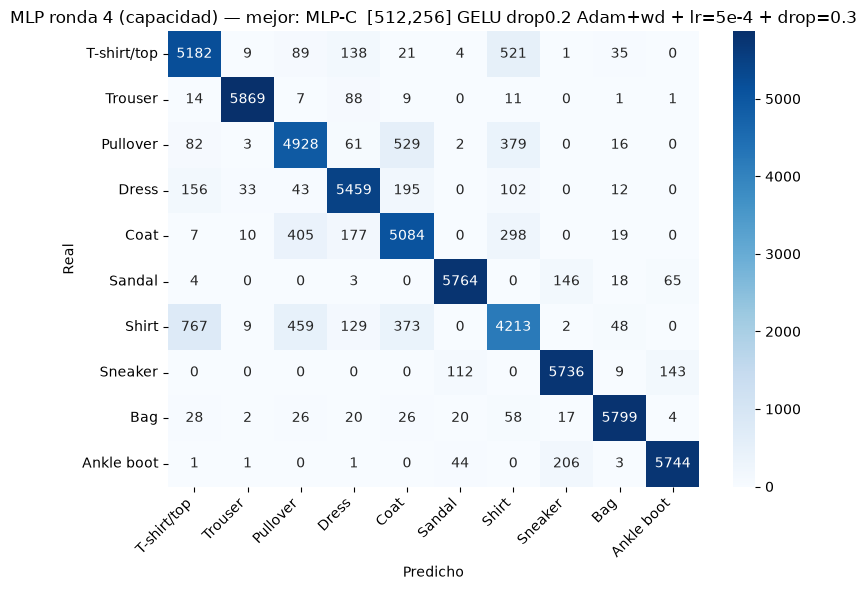


[MLP ronda 4 (capacidad)] -> ganador: MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4 + drop=0.3  (sin cambio: ganó la base)


In [92]:
# Ronda 4 — capacidad (ancho/profundidad)
mlp_spec, mlp_name = tune("MLP ronda 4 (capacidad)", mlp_spec, mlp_name,
    [("[256,128]", {"hidden": [256,128]}), ("[512,256,128]", {"hidden": [512,256,128]}), ("[1024,512]", {"hidden": [1024,512]})], mlp_config)


=== MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4 + drop=0.3 ===
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4 + drop=0.3] cargado de cache  (acc=0.8963  f1=0.8960  roc=0.9926)

=== MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4 + drop=0.3 + wd=0 ===
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4 + drop=0.3 + wd=0] cargado de cache  (acc=0.8969  f1=0.8966  roc=0.9927)

=== MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4 + drop=0.3 + wd=5e-4 ===
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4 + drop=0.3 + wd=5e-4] cargado de cache  (acc=0.8927  f1=0.8922  roc=0.9923)

Métricas de 'MLP ronda 5 (weight_decay)' guardadas en models/metrics/MLP_ronda_5_weight_decay.csv


,round,model,acc_mean,acc_std,prec_mean,rec_mean,f1_mean,f1_std,roc_mean
0,MLP ronda 5 (weight_decay),"MLP-C [512,256] GELU drop0.2 Adam+wd + lr=5e-...",0.896900,0.001188,0.896945,0.896900,0.896578,0.001239,0.992691
1,MLP ronda 5 (weight_decay),"MLP-C [512,256] GELU drop0.2 Adam+wd + lr=5e-...",0.896300,0.001147,0.896345,0.896300,0.895983,0.001410,0.992641
2,MLP ronda 5 (weight_decay),"MLP-C [512,256] GELU drop0.2 Adam+wd + lr=5e-...",0.892717,0.003400,0.892848,0.892717,0.892214,0.003281,0.992290



Mejor de 'MLP ronda 5 (weight_decay)': MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4 + drop=0.3 + wd=0  (f1=0.8966)
Reentrenando sobre todo el train y guardando...
  modelo cargado desde models/best_MLP_ronda_5_weight_decay.pth (no se reentrena)


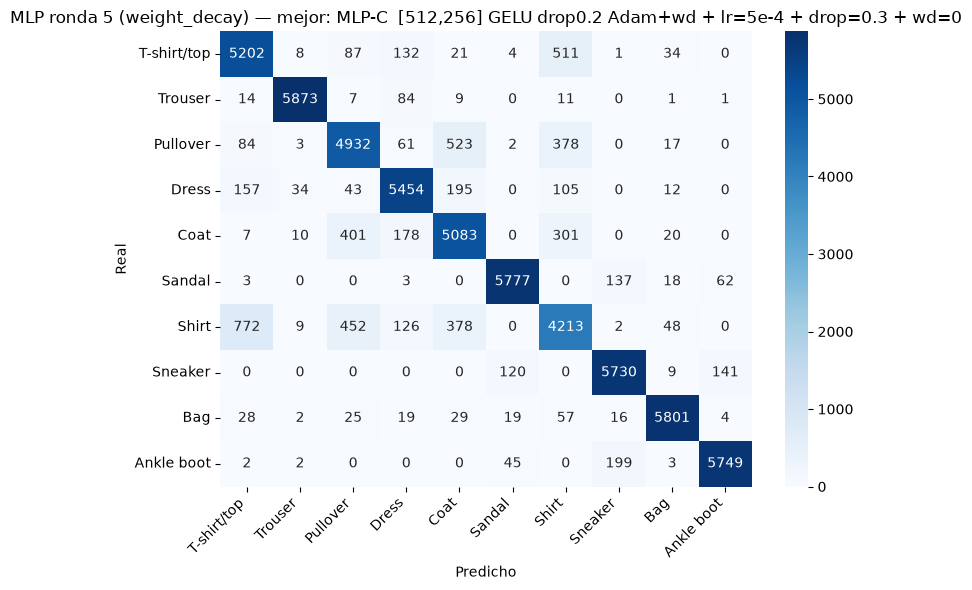


[MLP ronda 5 (weight_decay)] -> ganador: MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4 + drop=0.3 + wd=0  (cambió el ganador)


In [93]:
# Ronda 5 — weight decay (L2)
mlp_spec, mlp_name = tune("MLP ronda 5 (weight_decay)", mlp_spec, mlp_name,
    [("wd=0", {"wd": 0.0}), ("wd=5e-4", {"wd": 5e-4})], mlp_config)


=== MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4 + drop=0.3 + wd=0 ===
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4 + drop=0.3 + wd=0] cargado de cache  (acc=0.8969  f1=0.8966  roc=0.9927)

=== MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4 + drop=0.3 + wd=0 + RMSprop ===
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4 + drop=0.3 + wd=0 + RMSprop] cargado de cache  (acc=0.8940  f1=0.8934  roc=0.9925)

=== MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4 + drop=0.3 + wd=0 + SGD+mom lr=1e-2 ===
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4 + drop=0.3 + wd=0 + SGD+mom lr=1e-2] cargado de cache  (acc=0.8847  f1=0.8838  roc=0.9913)

Métricas de 'MLP ronda 6 (optimizador)' guardadas en models/metrics/MLP_ronda_6_optimizador.csv


,round,model,acc_mean,acc_std,prec_mean,rec_mean,f1_mean,f1_std,roc_mean
0,MLP ronda 6 (optimizador),"MLP-C [512,256] GELU drop0.2 Adam+wd + lr=5e-...",0.896900,0.001188,0.896945,0.896900,0.896578,0.001239,0.992691
1,MLP ronda 6 (optimizador),"MLP-C [512,256] GELU drop0.2 Adam+wd + lr=5e-...",0.894017,0.003508,0.894332,0.894017,0.893438,0.003131,0.992453
2,MLP ronda 6 (optimizador),"MLP-C [512,256] GELU drop0.2 Adam+wd + lr=5e-...",0.884667,0.002589,0.884274,0.884667,0.883797,0.002655,0.991320



Mejor de 'MLP ronda 6 (optimizador)': MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4 + drop=0.3 + wd=0  (f1=0.8966)
Reentrenando sobre todo el train y guardando...
  modelo cargado desde models/best_MLP_ronda_6_optimizador.pth (no se reentrena)


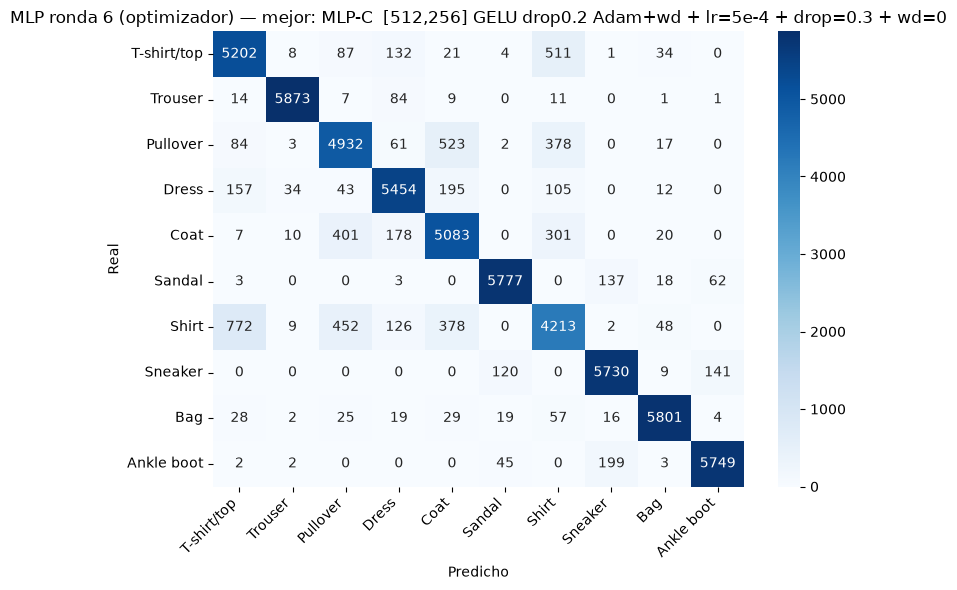


[MLP ronda 6 (optimizador)] -> ganador: MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4 + drop=0.3 + wd=0  (sin cambio: ganó la base)


In [94]:
# Ronda 6 — optimizador (SGD lleva su lr acoplado)
mlp_spec, mlp_name = tune("MLP ronda 6 (optimizador)", mlp_spec, mlp_name,
    [("RMSprop", {"opt": "rmsprop"}), ("SGD+mom lr=1e-2", {"opt": "sgd", "lr": 1e-2})], mlp_config)

##### Cadena de tuning — CNN

In [95]:
# Punto de partida CNN: ganador de la Ronda 1 (CNN-B). A partir de acá se encadena.
cnn_spec = dict(channels=[32, 64], conv_drop=0.25, fc=[256, 128], fc_drop=[0.5, 0.25],
                bn=True, opt="adam", lr=1e-3, wd=1e-4, epochs=20)
cnn_name = "CNN-B  BN [32,64]->256,128 dropout+wd"   # nombre cacheado de la Ronda 1


=== CNN-B  BN [32,64]->256,128 dropout+wd ===
  [CNN-B  BN [32,64]->256,128 dropout+wd] cargado de cache  (acc=0.9230  f1=0.9225  roc=0.9955)

=== CNN-B  BN [32,64]->256,128 dropout+wd + lr=5e-4 ===
  [CNN-B  BN [32,64]->256,128 dropout+wd + lr=5e-4] cargado de cache  (acc=0.9193  f1=0.9190  roc=0.9952)

=== CNN-B  BN [32,64]->256,128 dropout+wd + lr=2e-3 ===
  [CNN-B  BN [32,64]->256,128 dropout+wd + lr=2e-3] cargado de cache  (acc=0.9217  f1=0.9211  roc=0.9955)

Métricas de 'CNN ronda 2 (lr)' guardadas en models/metrics/CNN_ronda_2_lr.csv


,round,model,acc_mean,acc_std,prec_mean,rec_mean,f1_mean,f1_std,roc_mean
0,CNN ronda 2 (lr),"CNN-B BN [32,64]->256,128 dropout+wd",0.922967,0.003272,0.922577,0.922967,0.922501,0.003409,0.995509
1,CNN ronda 2 (lr),"CNN-B BN [32,64]->256,128 dropout+wd + lr=2e-3",0.921667,0.003243,0.921520,0.921667,0.921139,0.003296,0.995487
2,CNN ronda 2 (lr),"CNN-B BN [32,64]->256,128 dropout+wd + lr=5e-4",0.919283,0.003827,0.919464,0.919283,0.919039,0.003935,0.995228



Mejor de 'CNN ronda 2 (lr)': CNN-B  BN [32,64]->256,128 dropout+wd  (f1=0.9225)
Reentrenando sobre todo el train y guardando...
  modelo cargado desde models/best_CNN_ronda_2_lr.pth (no se reentrena)


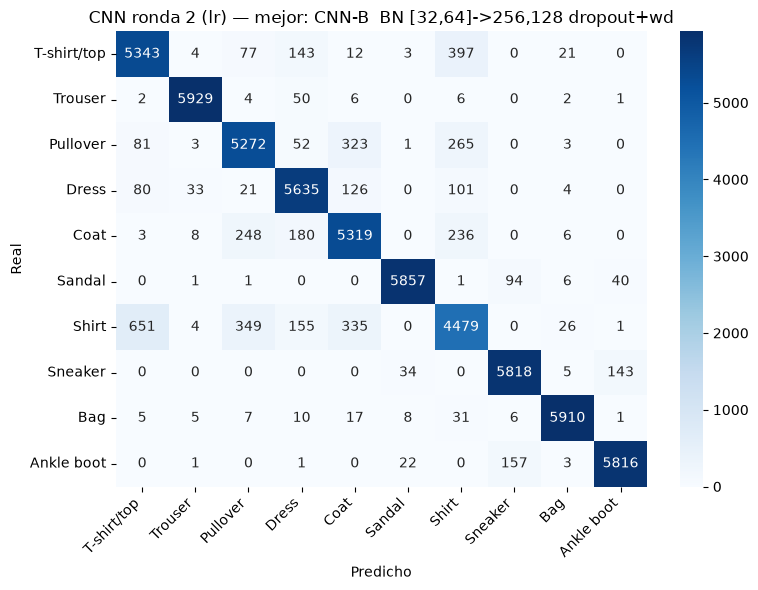


[CNN ronda 2 (lr)] -> ganador: CNN-B  BN [32,64]->256,128 dropout+wd  (sin cambio: ganó la base)


In [96]:
# Ronda 2 — learning rate
cnn_spec, cnn_name = tune("CNN ronda 2 (lr)", cnn_spec, cnn_name,
    [("lr=5e-4", {"lr": 5e-4}), ("lr=2e-3", {"lr": 2e-3})], cnn_config)


=== CNN-B  BN [32,64]->256,128 dropout+wd ===
  [CNN-B  BN [32,64]->256,128 dropout+wd] cargado de cache  (acc=0.9230  f1=0.9225  roc=0.9955)

=== CNN-B  BN [32,64]->256,128 dropout+wd + conv_drop=0.1 ===
  [CNN-B  BN [32,64]->256,128 dropout+wd + conv_drop=0.1] cargado de cache  (acc=0.9194  f1=0.9194  roc=0.9953)

=== CNN-B  BN [32,64]->256,128 dropout+wd + conv_drop=0.4 ===
  [CNN-B  BN [32,64]->256,128 dropout+wd + conv_drop=0.4] cargado de cache  (acc=0.9203  f1=0.9198  roc=0.9955)

Métricas de 'CNN ronda 3 (dropout)' guardadas en models/metrics/CNN_ronda_3_dropout.csv


,round,model,acc_mean,acc_std,prec_mean,rec_mean,f1_mean,f1_std,roc_mean
0,CNN ronda 3 (dropout),"CNN-B BN [32,64]->256,128 dropout+wd",0.922967,0.003272,0.922577,0.922967,0.922501,0.003409,0.995509
1,CNN ronda 3 (dropout),"CNN-B BN [32,64]->256,128 dropout+wd + conv_d...",0.920317,0.003072,0.920228,0.920317,0.919796,0.003128,0.995458
2,CNN ronda 3 (dropout),"CNN-B BN [32,64]->256,128 dropout+wd + conv_d...",0.919450,0.001451,0.920125,0.919450,0.919404,0.001250,0.995289



Mejor de 'CNN ronda 3 (dropout)': CNN-B  BN [32,64]->256,128 dropout+wd  (f1=0.9225)
Reentrenando sobre todo el train y guardando...
  modelo cargado desde models/best_CNN_ronda_3_dropout.pth (no se reentrena)


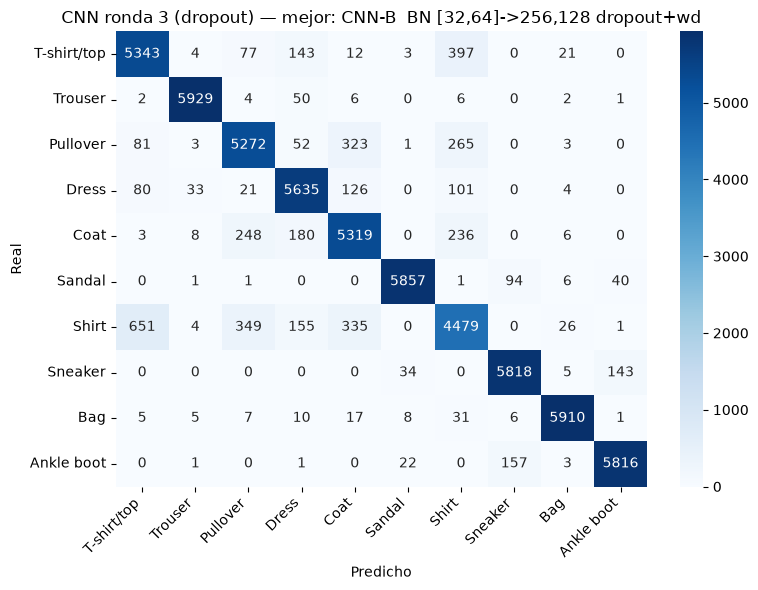


[CNN ronda 3 (dropout)] -> ganador: CNN-B  BN [32,64]->256,128 dropout+wd  (sin cambio: ganó la base)


In [97]:
# Ronda 3 — dropout (en la 2da conv)
cnn_spec, cnn_name = tune("CNN ronda 3 (dropout)", cnn_spec, cnn_name,
    [("conv_drop=0.1", {"conv_drop": 0.1}), ("conv_drop=0.4", {"conv_drop": 0.4})], cnn_config)


=== CNN-B  BN [32,64]->256,128 dropout+wd ===
  [CNN-B  BN [32,64]->256,128 dropout+wd] cargado de cache  (acc=0.9230  f1=0.9225  roc=0.9955)

=== CNN-B  BN [32,64]->256,128 dropout+wd + [16,32] ===
  [CNN-B  BN [32,64]->256,128 dropout+wd + [16,32]] cargado de cache  (acc=0.9171  f1=0.9168  roc=0.9952)

=== CNN-B  BN [32,64]->256,128 dropout+wd + [64,128] ===
  [CNN-B  BN [32,64]->256,128 dropout+wd + [64,128]] cargado de cache  (acc=0.9226  f1=0.9222  roc=0.9956)

Métricas de 'CNN ronda 4 (capacidad)' guardadas en models/metrics/CNN_ronda_4_capacidad.csv


,round,model,acc_mean,acc_std,prec_mean,rec_mean,f1_mean,f1_std,roc_mean
0,CNN ronda 4 (capacidad),"CNN-B BN [32,64]->256,128 dropout+wd",0.922967,0.003272,0.922577,0.922967,0.922501,0.003409,0.995509
1,CNN ronda 4 (capacidad),"CNN-B BN [32,64]->256,128 dropout+wd + [64,128]",0.922567,0.004613,0.922639,0.922567,0.922206,0.004593,0.995576
2,CNN ronda 4 (capacidad),"CNN-B BN [32,64]->256,128 dropout+wd + [16,32]",0.917050,0.002678,0.917221,0.917050,0.916824,0.002509,0.995161



Mejor de 'CNN ronda 4 (capacidad)': CNN-B  BN [32,64]->256,128 dropout+wd  (f1=0.9225)
Reentrenando sobre todo el train y guardando...
  modelo cargado desde models/best_CNN_ronda_4_capacidad.pth (no se reentrena)


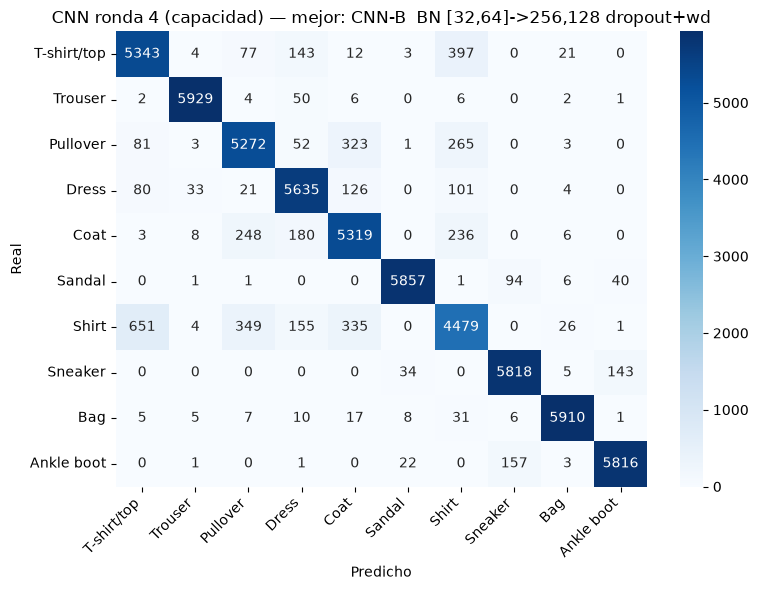


[CNN ronda 4 (capacidad)] -> ganador: CNN-B  BN [32,64]->256,128 dropout+wd  (sin cambio: ganó la base)


In [98]:
# Ronda 4 — capacidad (canales convolucionales)
cnn_spec, cnn_name = tune("CNN ronda 4 (capacidad)", cnn_spec, cnn_name,
    [("[16,32]", {"channels": [16,32]}), ("[64,128]", {"channels": [64,128]})], cnn_config)


=== CNN-B  BN [32,64]->256,128 dropout+wd ===
  [CNN-B  BN [32,64]->256,128 dropout+wd] cargado de cache  (acc=0.9230  f1=0.9225  roc=0.9955)

=== CNN-B  BN [32,64]->256,128 dropout+wd + wd=0 ===
  [CNN-B  BN [32,64]->256,128 dropout+wd + wd=0] cargado de cache  (acc=0.9206  f1=0.9199  roc=0.9955)

=== CNN-B  BN [32,64]->256,128 dropout+wd + wd=5e-4 ===
  [CNN-B  BN [32,64]->256,128 dropout+wd + wd=5e-4] cargado de cache  (acc=0.9191  f1=0.9186  roc=0.9954)

Métricas de 'CNN ronda 5 (weight_decay)' guardadas en models/metrics/CNN_ronda_5_weight_decay.csv


,round,model,acc_mean,acc_std,prec_mean,rec_mean,f1_mean,f1_std,roc_mean
0,CNN ronda 5 (weight_decay),"CNN-B BN [32,64]->256,128 dropout+wd",0.922967,0.003272,0.922577,0.922967,0.922501,0.003409,0.995509
1,CNN ronda 5 (weight_decay),"CNN-B BN [32,64]->256,128 dropout+wd + wd=0",0.920567,0.002008,0.920616,0.920567,0.919905,0.002135,0.995458
2,CNN ronda 5 (weight_decay),"CNN-B BN [32,64]->256,128 dropout+wd + wd=5e-4",0.919150,0.001787,0.919244,0.919150,0.918588,0.001645,0.995367



Mejor de 'CNN ronda 5 (weight_decay)': CNN-B  BN [32,64]->256,128 dropout+wd  (f1=0.9225)
Reentrenando sobre todo el train y guardando...
  modelo cargado desde models/best_CNN_ronda_5_weight_decay.pth (no se reentrena)


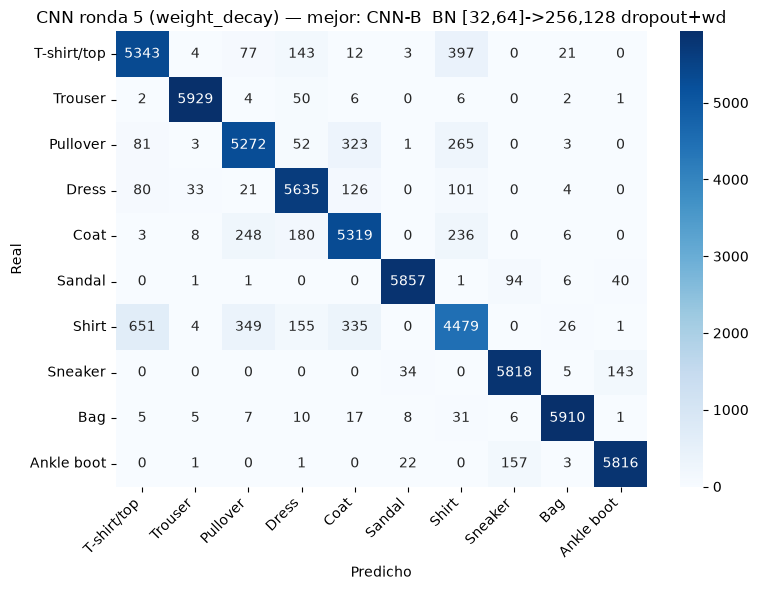


[CNN ronda 5 (weight_decay)] -> ganador: CNN-B  BN [32,64]->256,128 dropout+wd  (sin cambio: ganó la base)


In [99]:
# Ronda 5 — weight decay (L2)
cnn_spec, cnn_name = tune("CNN ronda 5 (weight_decay)", cnn_spec, cnn_name,
    [("wd=0", {"wd": 0.0}), ("wd=5e-4", {"wd": 5e-4})], cnn_config)


=== CNN-B  BN [32,64]->256,128 dropout+wd ===
  [CNN-B  BN [32,64]->256,128 dropout+wd] cargado de cache  (acc=0.9230  f1=0.9225  roc=0.9955)

=== CNN-B  BN [32,64]->256,128 dropout+wd + RMSprop ===
  [CNN-B  BN [32,64]->256,128 dropout+wd + RMSprop] cargado de cache  (acc=0.9074  f1=0.9067  roc=0.9942)

=== CNN-B  BN [32,64]->256,128 dropout+wd + SGD+mom lr=1e-2 ===
  [CNN-B  BN [32,64]->256,128 dropout+wd + SGD+mom lr=1e-2] cargado de cache  (acc=0.9153  f1=0.9147  roc=0.9949)

Métricas de 'CNN ronda 6 (optimizador)' guardadas en models/metrics/CNN_ronda_6_optimizador.csv


,round,model,acc_mean,acc_std,prec_mean,rec_mean,f1_mean,f1_std,roc_mean
0,CNN ronda 6 (optimizador),"CNN-B BN [32,64]->256,128 dropout+wd",0.922967,0.003272,0.922577,0.922967,0.922501,0.003409,0.995509
1,CNN ronda 6 (optimizador),"CNN-B BN [32,64]->256,128 dropout+wd + SGD+mo...",0.915250,0.002015,0.915351,0.915250,0.914685,0.002355,0.994867
2,CNN ronda 6 (optimizador),"CNN-B BN [32,64]->256,128 dropout+wd + RMSprop",0.907450,0.006193,0.909020,0.907450,0.906741,0.006207,0.994167



Mejor de 'CNN ronda 6 (optimizador)': CNN-B  BN [32,64]->256,128 dropout+wd  (f1=0.9225)
Reentrenando sobre todo el train y guardando...
  modelo cargado desde models/best_CNN_ronda_6_optimizador.pth (no se reentrena)


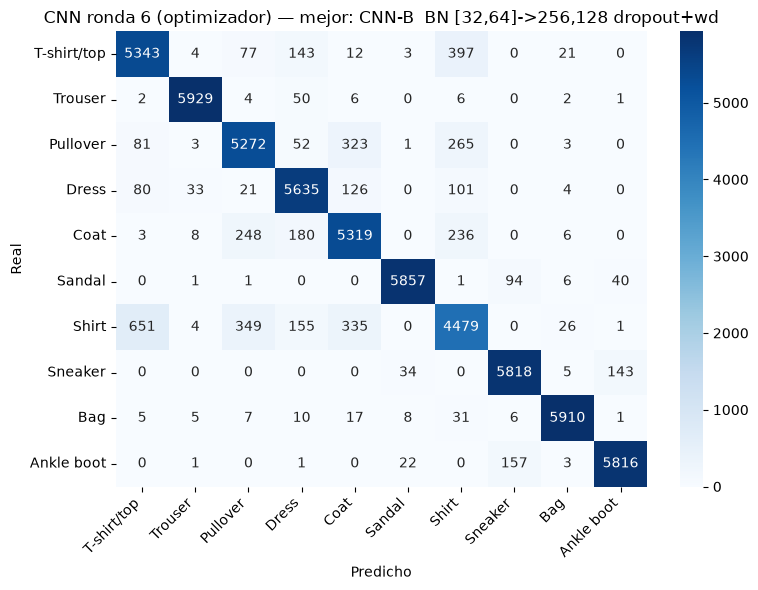


[CNN ronda 6 (optimizador)] -> ganador: CNN-B  BN [32,64]->256,128 dropout+wd  (sin cambio: ganó la base)


In [100]:
# Ronda 6 — optimizador (SGD lleva su lr acoplado)
cnn_spec, cnn_name = tune("CNN ronda 6 (optimizador)", cnn_spec, cnn_name,
    [("RMSprop", {"opt": "rmsprop"}), ("SGD+mom lr=1e-2", {"opt": "sgd", "lr": 1e-2})], cnn_config)

### 5.5 Evaluación final en test (held-out)

Una vez elegidos los mejores MLP y CNN, se reentrenan sobre **todo** el train y se evalúan
en `test_set`, que no participó en la selección. Esta es la métrica que decide el modelo final.

In [101]:
# Esta función toca el test una sola vez, cuando ya está decidido qué MLP y qué CNN evaluar.
# Eso evita usar el conjunto final para tomar decisiones de tuning.
def evaluate_on_test(name, model_fn, build_optimizer, num_epochs,
                     l1_lambda=0.0, patience=PATIENCE, batch_size=512, force=False):
    """
    Reentrena el modelo sobre TODO el train (con early stopping) y lo evalúa en el test held-out.
    Guarda el modelo en models/<name>_final.pth y lo carga si ya existe (no reentrena).
    """
    # Reutilizamos pesos guardados para no repetir entrenamientos costosos si el notebook se reejecuta.
    path = os.path.join(FINAL_DIR, f"{_slug(name)}_final.pth")
    torch.manual_seed(SEED)
    model = model_fn().to(device)

    if not force and not FORCE_RECOMPUTE and os.path.exists(path):
        model.load_state_dict(torch.load(path, map_location=device))
        print(f"Modelo cargado desde {path} (no se reentrena)")
    else:
        criterion = nn.CrossEntropyLoss()
        optimizer = build_optimizer(model)
        idx = np.arange(len(train_full))
        # Aun reentrenando sobre todo el train, dejamos una porción interna para frenar antes del sobreajuste.
        if patience > 0:
            tr_idx, va_idx = train_test_split(
                idx, test_size=INNER_VAL_FRAC, random_state=SEED, stratify=cv_labels)
            train_loader = GPULoader(X_train_gpu, Y_train_gpu, tr_idx, batch_size, True)
            es_loader    = GPULoader(X_train_gpu, Y_train_gpu, va_idx, batch_size, False)
        else:
            train_loader = GPULoader(X_train_gpu, Y_train_gpu, None, batch_size, True)
            es_loader    = None
        print(f"Entrenando {name} sobre el train completo (máx {num_epochs} épocas, early stopping)...")
        _fit(model, train_loader, es_loader, criterion, optimizer, num_epochs, l1_lambda, patience)
        torch.save(model.state_dict(), path)
        print(f"Modelo guardado en {path}")

    # En test no hay shuffle: queremos una evaluación determinista y reproducible.
    test_loader_eval = GPULoader(X_test_gpu, Y_test_gpu, None, batch_size, False)
    y_true, y_pred, y_proba = _predict(model, test_loader_eval)

    print(f"\n=== Test — {name} ===")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))
    roc = roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro")
    print(f"ROC-AUC (macro, OvR): {roc:.4f}")
    plot_cm(confusion_matrix(y_true, y_pred, labels=list(range(10))), f"Test — {name}")
    plot_roc(y_true, y_proba, f"ROC (test) — {name}")
    return model

# Ejemplo de uso una vez decididos los ganadores (descomentar y ajustar):
# best_mlp = evaluate_on_test("MLP final",
#     model_fn=lambda: MLPForCV([512, 256, 128], nn.ReLU, 0.3),
#     build_optimizer=lambda m: optim.Adam(m.parameters(), lr=1e-3), num_epochs=30)

Modelo cargado desde models/MLP_final_final.pth (no se reentrena)

=== Test — MLP final ===
              precision    recall  f1-score   support

 T-shirt/top     0.8408    0.8450    0.8429      1000
     Trouser     0.9868    0.9720    0.9793      1000
    Pullover     0.8006    0.8150    0.8077      1000
       Dress     0.8776    0.8960    0.8867      1000
        Coat     0.7842    0.8430    0.8125      1000
      Sandal     0.9772    0.9420    0.9593      1000
       Shirt     0.7377    0.6580    0.6956      1000
     Sneaker     0.9248    0.9590    0.9416      1000
         Bag     0.9749    0.9720    0.9735      1000
  Ankle boot     0.9543    0.9600    0.9571      1000

    accuracy                         0.8862     10000
   macro avg     0.8859    0.8862    0.8856     10000
weighted avg     0.8859    0.8862    0.8856     10000

ROC-AUC (macro, OvR): 0.9913


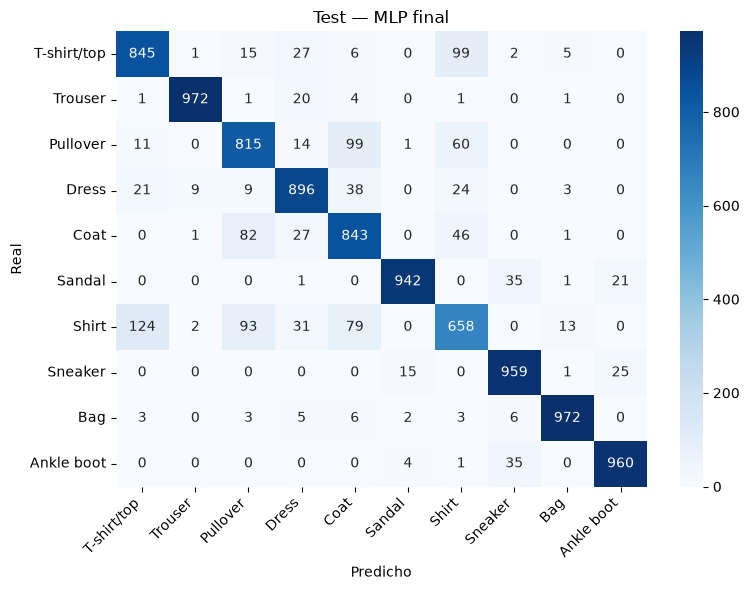

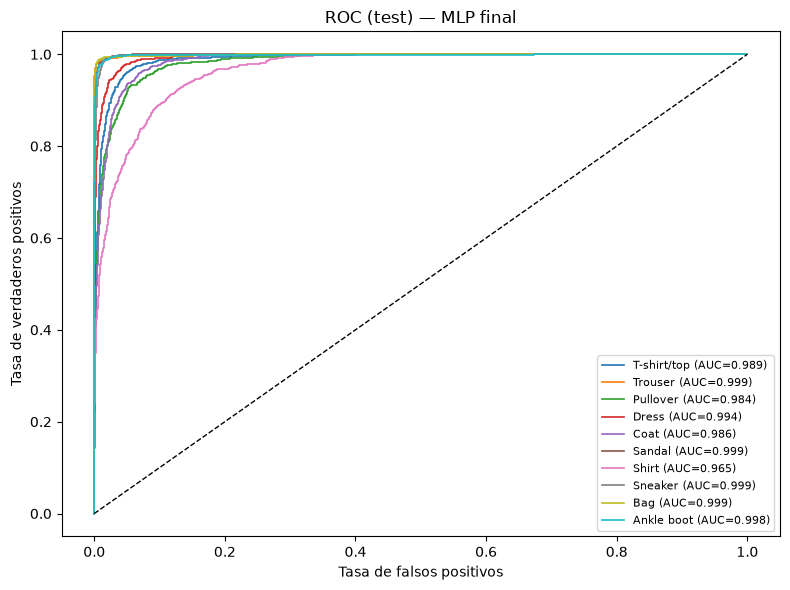

Modelo cargado desde models/CNN_final_final.pth (no se reentrena)

=== Test — CNN final ===
              precision    recall  f1-score   support

 T-shirt/top     0.8379    0.9200    0.8770      1000
     Trouser     0.9774    0.9940    0.9856      1000
    Pullover     0.8629    0.8940    0.8782      1000
       Dress     0.9320    0.9180    0.9249      1000
        Coat     0.8953    0.8720    0.8835      1000
      Sandal     0.9869    0.9820    0.9845      1000
       Shirt     0.8131    0.7180    0.7626      1000
     Sneaker     0.9524    0.9800    0.9660      1000
         Bag     0.9850    0.9870    0.9860      1000
  Ankle boot     0.9827    0.9640    0.9732      1000

    accuracy                         0.9229     10000
   macro avg     0.9226    0.9229    0.9222     10000
weighted avg     0.9226    0.9229    0.9222     10000

ROC-AUC (macro, OvR): 0.9955


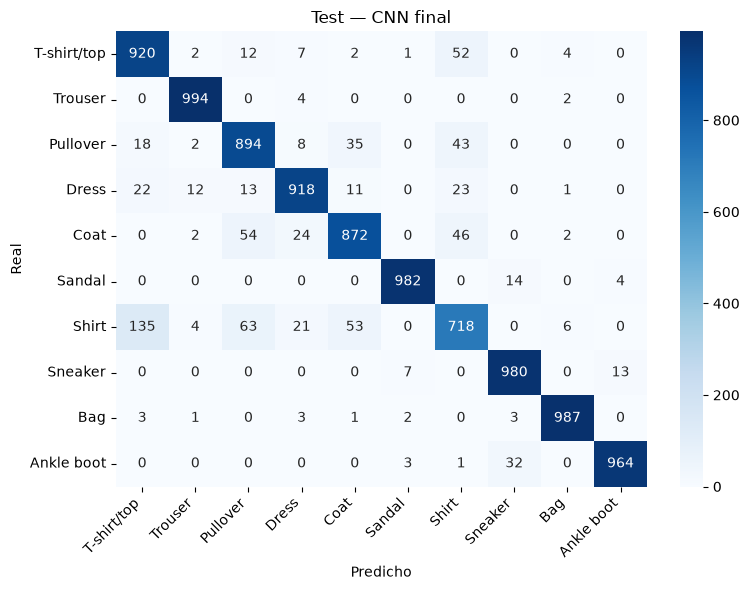

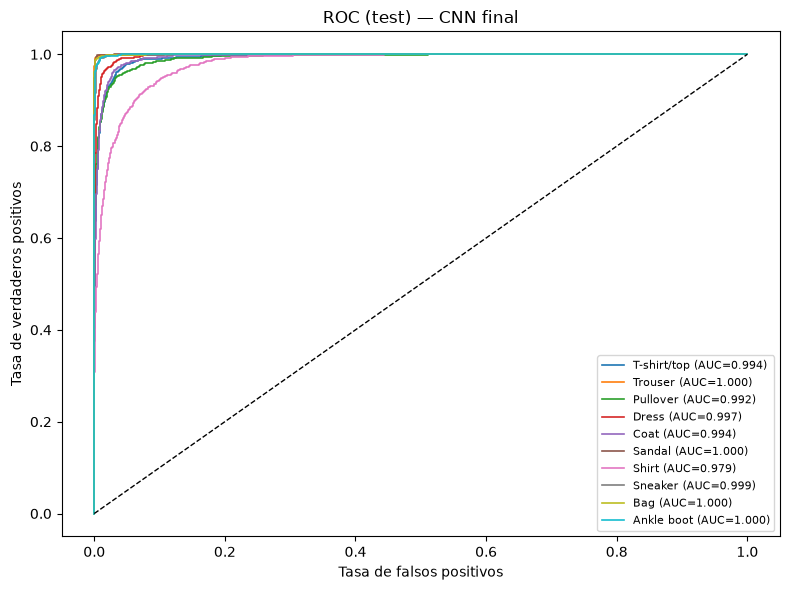

In [102]:
# === Evaluación final en test + guardado del GANADOR de toda la cadena de tuning =====
# mlp_spec / cnn_spec contienen la mejor combinación acumulada (ver sección 5.4).
# Esta es la ÚNICA vez que se toca el test held-out.

mlp_final = mlp_config("MLP final", mlp_spec)
best_mlp = evaluate_on_test(mlp_final["name"], model_fn=mlp_final["model_fn"],
                            build_optimizer=mlp_final["build_optimizer"],
                            num_epochs=mlp_final["num_epochs"])

cnn_final = cnn_config("CNN final", cnn_spec)
best_cnn = evaluate_on_test(cnn_final["name"], model_fn=cnn_final["model_fn"],
                            build_optimizer=cnn_final["build_optimizer"],
                            num_epochs=cnn_final["num_epochs"])

# 6. Discusión

## 6.1 Modelos seleccionados

A partir de la etapa de experimentación ya quedaron definidos **un único MLP ganador** y **una única CNN ganadora**. En esta discusión se trabaja solo con esos dos modelos finales, que son los que se reentrenan sobre el conjunto de entrenamiento y luego se evalúan en `test_set`.

In [103]:
from IPython.display import Markdown


def count_parameters(model):
    return sum(p.numel() for p in model.parameters())


def evaluate_saved_model(model, name, batch_size=512):
    loader = GPULoader(X_test_gpu, Y_test_gpu, None, batch_size, False)
    y_true, y_pred, y_proba = _predict(model, loader)
    metrics = _metrics(y_true, y_pred, y_proba)
    cm = confusion_matrix(y_true, y_pred, labels=list(range(10)))
    return {
        "name": name,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_proba": y_proba,
        "metrics": metrics,
        "cm": cm,
    }


def top_confusions(cm, top_k=3):
    pairs = []
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if i != j and cm[i, j] > 0:
                pairs.append((CLASS_NAMES[i], CLASS_NAMES[j], int(cm[i, j])))
    pairs.sort(key=lambda x: x[2], reverse=True)
    return pairs[:top_k]


def format_confusions(confusions):
    return "; ".join([f"{real} → {pred} ({count})" for real, pred, count in confusions])


def qualitative_observation(model_type, metrics, confusions):
    if model_type == "MLP":
        return (
            f"Baseline denso competitivo; accuracy={metrics['accuracy']:.4f}. "
            f"Sus errores se concentran en clases visualmente similares: {format_confusions(confusions)}."
        )
    return (
        f"Aprovecha mejor la estructura espacial; accuracy={metrics['accuracy']:.4f}. "
        f"Mantiene confusiones en clases parecidas, pero con menor impacto relativo: {format_confusions(confusions)}."
    )


def plot_prediction_examples(results, title, correct=True, n=3):
    y_true = results["y_true"]
    y_pred = results["y_pred"]
    matches = np.where(y_true == y_pred)[0] if correct else np.where(y_true != y_pred)[0]
    n = min(n, len(matches))
    chosen = matches[:n]

    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]

    for ax, idx in zip(axes, chosen):
        image = X_test_gpu[idx].detach().cpu().numpy().squeeze()
        image = image * std.item() + mean.item()
        ax.imshow(image, cmap="gray")
        ax.set_title(
            f"Real: {CLASS_NAMES[y_true[idx]]}\nPred: {CLASS_NAMES[y_pred[idx]]}",
            fontsize=10,
        )
        ax.axis("off")

    label = "correctas" if correct else "incorrectas"
    plt.suptitle(f"{title} — predicciones {label}")
    plt.tight_layout()
    plt.show()

In [104]:
selected_models_table = pd.DataFrame([
    {
        "modelo": "MLP",
        "nombre": mlp_final["name"],
        "epocas_configuradas": mlp_final["num_epochs"],
        "parametros": count_parameters(best_mlp),
    },
    {
        "modelo": "CNN",
        "nombre": cnn_final["name"],
        "epocas_configuradas": cnn_final["num_epochs"],
        "parametros": count_parameters(best_cnn),
    },
])

display(selected_models_table)

,modelo,nombre,epocas_configuradas,parametros
0,MLP,MLP final,25,535818
1,CNN,CNN final,20,856266


## 6.2 Comparación final en test

La siguiente comparación usa únicamente los dos modelos finales seleccionados: el mejor **MLP** y la mejor **CNN**. Sobre ellos se calcula accuracy en test, se inspeccionan las matrices de confusión y se muestran ejemplos de aciertos y errores.

In [105]:
# A partir de los dos mejores modelos calculamos exactamente las salidas pedidas en el enunciado.
mlp_test_results = evaluate_saved_model(best_mlp, mlp_final["name"])
cnn_test_results = evaluate_saved_model(best_cnn, cnn_final["name"])

mlp_confusions = top_confusions(mlp_test_results["cm"], top_k=3)
cnn_confusions = top_confusions(cnn_test_results["cm"], top_k=3)

final_test_table = pd.DataFrame([
    {
        "modelo": "MLP",
        "accuracy_test": mlp_test_results["metrics"]["accuracy"],
        "parametros": count_parameters(best_mlp),
        "epocas_configuradas": mlp_final["num_epochs"],
        "observaciones_cualitativas": qualitative_observation("MLP", mlp_test_results["metrics"], mlp_confusions),
    },
    {
        "modelo": "CNN",
        "accuracy_test": cnn_test_results["metrics"]["accuracy"],
        "parametros": count_parameters(best_cnn),
        "epocas_configuradas": cnn_final["num_epochs"],
        "observaciones_cualitativas": qualitative_observation("CNN", cnn_test_results["metrics"], cnn_confusions),
    },
])

with pd.option_context("display.max_colwidth", None):
    display(final_test_table)

,modelo,accuracy_test,parametros,epocas_configuradas,observaciones_cualitativas
0,MLP,0.8862,535818,25,Baseline denso competitivo; accuracy=0.8862. Sus errores se concentran en clases visualmente similares: Shirt → T-shirt/top (124); T-shirt/top → Shirt (99); Pullover → Coat (99).
1,CNN,0.9229,856266,20,"Aprovecha mejor la estructura espacial; accuracy=0.9229. Mantiene confusiones en clases parecidas, pero con menor impacto relativo: Shirt → T-shirt/top (135); Shirt → Pullover (63); Coat → Pullover (54)."


Accuracy final del MLP: 0.8862
Accuracy final de la CNN: 0.9229

Top 3 confusiones del MLP:
- Shirt → T-shirt/top: 124
- T-shirt/top → Shirt: 99
- Pullover → Coat: 99

Top 3 confusiones de la CNN:
- Shirt → T-shirt/top: 135
- Shirt → Pullover: 63
- Coat → Pullover: 54


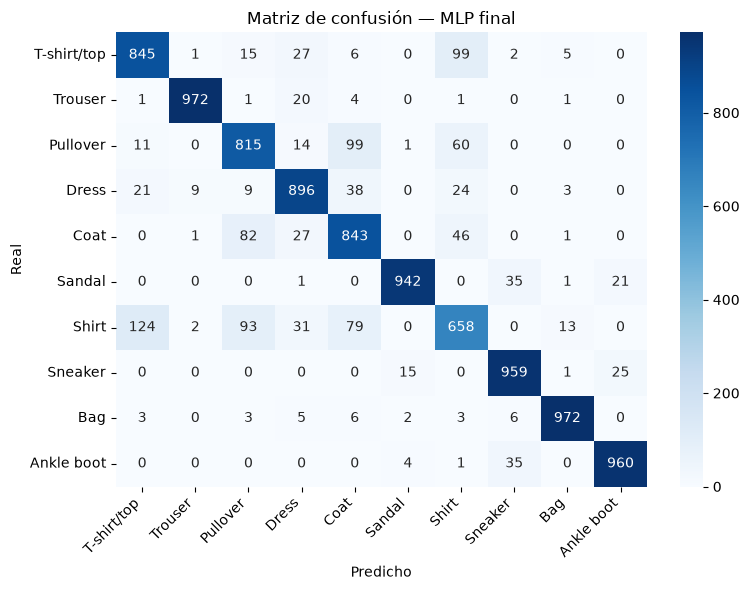

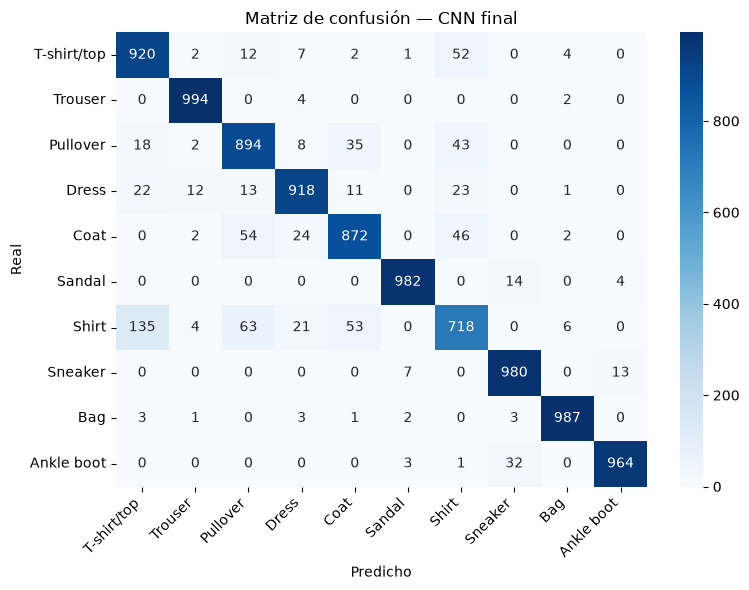

In [106]:
# Resumen textual rápido: accuracy final y clases que más se confunden en cada arquitectura.
print("Accuracy final del MLP:", round(mlp_test_results["metrics"]["accuracy"], 4))
print("Accuracy final de la CNN:", round(cnn_test_results["metrics"]["accuracy"], 4))

print("\nTop 3 confusiones del MLP:")
for real, pred, count in mlp_confusions:
    print(f"- {real} → {pred}: {count}")

print("\nTop 3 confusiones de la CNN:")
for real, pred, count in cnn_confusions:
    print(f"- {real} → {pred}: {count}")

plot_cm(mlp_test_results["cm"], f"Matriz de confusión — {mlp_final['name']}")
plot_cm(cnn_test_results["cm"], f"Matriz de confusión — {cnn_final['name']}")

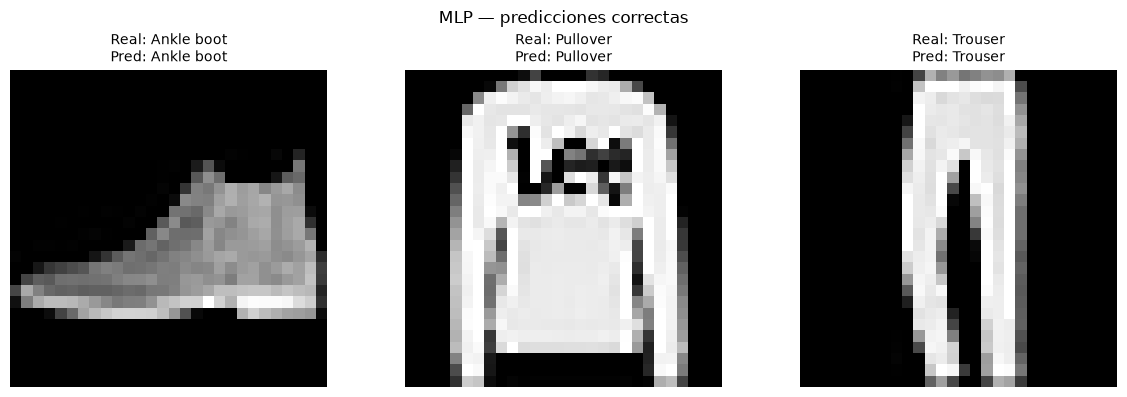

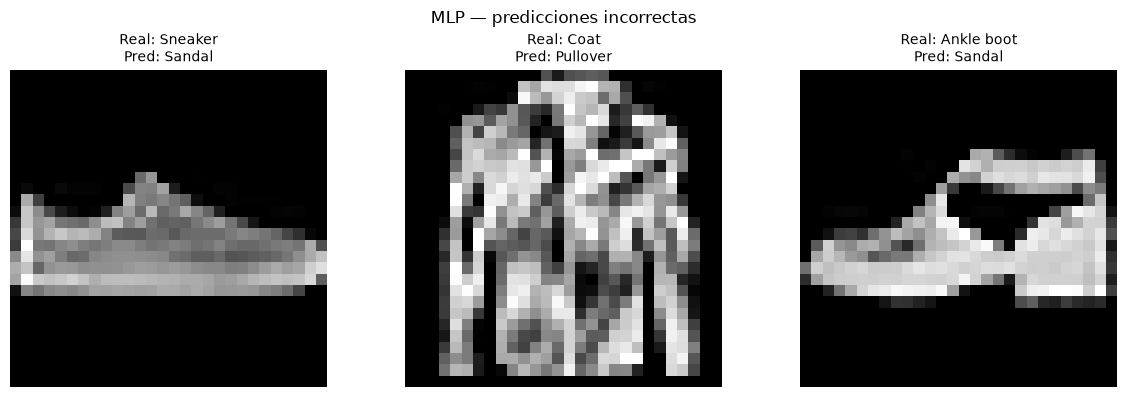

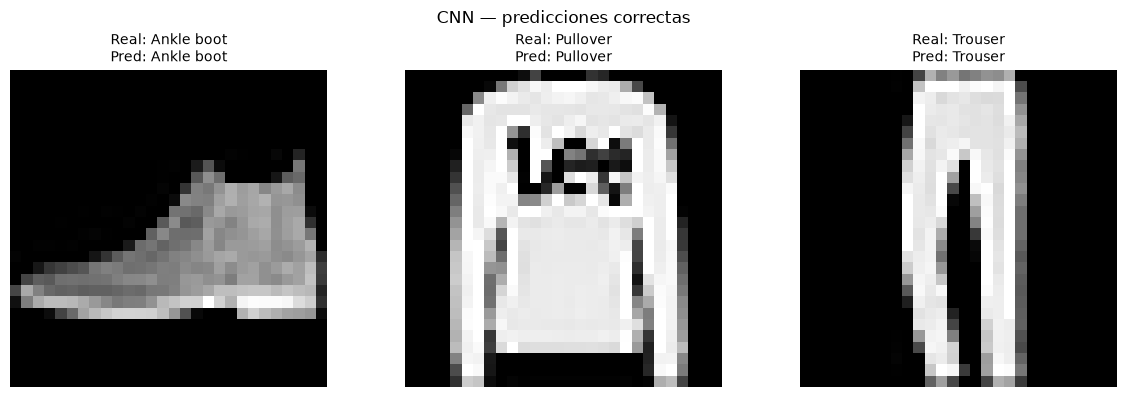

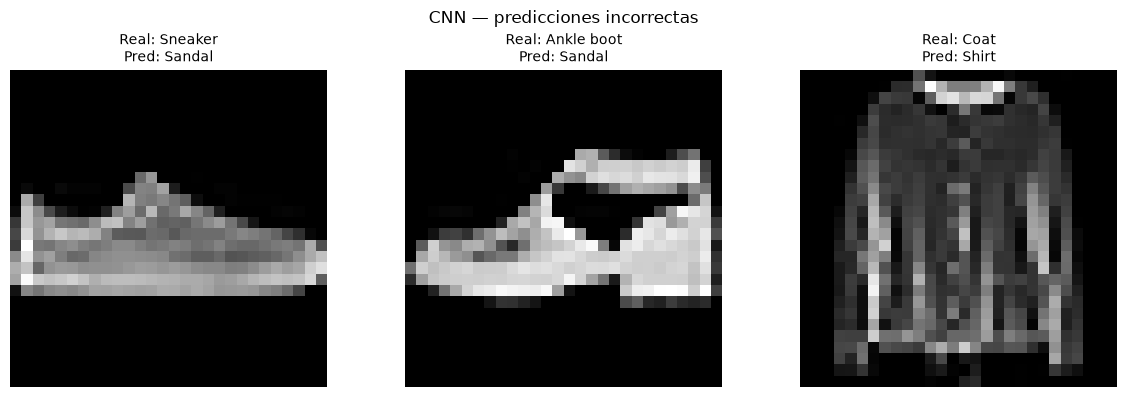

In [107]:
# Mostramos ejemplos concretos para conectar la métrica agregada con comportamientos observables del modelo.
plot_prediction_examples(mlp_test_results, "MLP", correct=True, n=3)
plot_prediction_examples(mlp_test_results, "MLP", correct=False, n=3)
plot_prediction_examples(cnn_test_results, "CNN", correct=True, n=3)
plot_prediction_examples(cnn_test_results, "CNN", correct=False, n=3)

In [108]:
winner = "CNN" if cnn_test_results["metrics"]["accuracy"] > mlp_test_results["metrics"]["accuracy"] else "MLP"
acc_gap = abs(cnn_test_results["metrics"]["accuracy"] - mlp_test_results["metrics"]["accuracy"])

summary_md = f"""
## 6.3 Análisis de los resultados

La discusión final se centra exclusivamente en los dos modelos elegidos al terminar el proceso de tuning: un **MLP final** y una **CNN final**. Por lo tanto, el análisis no compara todas las variantes probadas, sino únicamente las dos arquitecturas que llegaron a la evaluación definitiva sobre `test_set`.

En este escenario, el modelo con mejor rendimiento fue el **{winner}**. La diferencia de accuracy entre ambos fue de **{acc_gap:.4f}**.

- **MLP final**: accuracy = **{mlp_test_results['metrics']['accuracy']:.4f}**.
- **CNN final**: accuracy = **{cnn_test_results['metrics']['accuracy']:.4f}**.

Las principales confusiones del **MLP** fueron **{format_confusions(mlp_confusions)}**. Esto muestra que el modelo denso tiene más dificultad para separar clases visualmente cercanas cuando la diferencia depende de patrones espaciales locales.

Las principales confusiones de la **CNN** fueron **{format_confusions(cnn_confusions)}**. Aunque todavía aparecen errores entre clases similares, la CNN los maneja mejor porque conserva la estructura bidimensional de la imagen durante el procesamiento.

La tabla comparativa de test resume exactamente lo pedido por el enunciado: accuracy final, cantidad de parámetros, número de épocas configuradas y una observación cualitativa para cada uno de los dos modelos seleccionados.
"""

display(Markdown(summary_md))


## 6.3 Análisis de los resultados

La discusión final se centra exclusivamente en los dos modelos elegidos al terminar el proceso de tuning: un **MLP final** y una **CNN final**. Por lo tanto, el análisis no compara todas las variantes probadas, sino únicamente las dos arquitecturas que llegaron a la evaluación definitiva sobre `test_set`.

En este escenario, el modelo con mejor rendimiento fue el **CNN**. La diferencia de accuracy entre ambos fue de **0.0367**.

- **MLP final**: accuracy = **0.8862**.
- **CNN final**: accuracy = **0.9229**.

Las principales confusiones del **MLP** fueron **Shirt → T-shirt/top (124); T-shirt/top → Shirt (99); Pullover → Coat (99)**. Esto muestra que el modelo denso tiene más dificultad para separar clases visualmente cercanas cuando la diferencia depende de patrones espaciales locales.

Las principales confusiones de la **CNN** fueron **Shirt → T-shirt/top (135); Shirt → Pullover (63); Coat → Pullover (54)**. Aunque todavía aparecen errores entre clases similares, la CNN los maneja mejor porque conserva la estructura bidimensional de la imagen durante el procesamiento.

La tabla comparativa de test resume exactamente lo pedido por el enunciado: accuracy final, cantidad de parámetros, número de épocas configuradas y una observación cualitativa para cada uno de los dos modelos seleccionados.


# 7. Conclusiones y Trabajo Futuro

In [109]:
winner_model = "CNN" if cnn_test_results["metrics"]["accuracy"] > mlp_test_results["metrics"]["accuracy"] else "MLP"
winner_acc = max(cnn_test_results["metrics"]["accuracy"], mlp_test_results["metrics"]["accuracy"])

conclusions_md = f"""
## 7.1 Conclusiones

El modelo con mejor rendimiento final fue la **{winner_model}**, con una accuracy de test de **{winner_acc:.4f}**. La principal razón es que las CNN están diseñadas específicamente para procesar imágenes: preservan la estructura espacial, comparten pesos y detectan patrones locales como bordes, contornos y texturas. En un problema como FashionMNIST, esas propiedades son especialmente valiosas para distinguir clases que cambian por detalles visuales sutiles.

## 7.2 ¿En qué clases se confunden más?

- En el **MLP**, las mayores confusiones fueron **{format_confusions(mlp_confusions)}**.
- En la **CNN**, las mayores confusiones fueron **{format_confusions(cnn_confusions)}**.

En ambos modelos aparecen sobre todo errores entre categorías de ropa superior, como `Shirt`, `T-shirt/top`, `Pullover` y `Coat`, porque comparten siluetas y niveles de textura parecidos en imágenes pequeñas de 28x28 píxeles.

## 7.3 Ventajas y limitaciones de MLP vs CNN

- **MLP**: Es mas sencillo de entender y de implementar, donde se ven claramente conceptos de capas, pesos o función de activación, sin embargo al usarlo con imágenes se debe aplanar la imagen haciendo que afecte su desempeño por la pérdida de estructura espacial y cueste mas que de buenos resultados. Además esto puede hacer que si la imagen se debe aplanar y es una resolución grande, la cantidad de entradas puede ser mucho para el modelo.
- **CNN**: Justamente este tipo de modelo es ideal para trabajar con datos de estructura espacial como imágenes, el cual usa filtros para encontrar patrones locales. Esto hace que tenga ventajas como que conserva la información espacial donde si hay una línea, una curva o una textura, la CNN puede detectarla porque analiza grupos cercanos de píxeles. Otra ventaja importante es que usa compartición de pesos. Un mismo filtro se aplica en distintas zonas de la imagen. Eso permite detectar un patrón esté donde esté. Sin embargo la limitación es que es mucho mas difícil de comprender el modelo desarrollado y que es lo que esta haciendo por dentro.

## 7.4 ¿Por qué las CNN suelen ser superiores en visión por computadora?

Las CNN son generalmente superiores porque incorporan **inductive bias espacial**. Un filtro convolucional puede detectar el mismo patrón en distintas posiciones de la imagen, lo que mejora eficiencia estadística y capacidad de generalización. Además, el pooling y la jerarquía de capas ayudan a construir representaciones cada vez más abstractas, desde bordes simples hasta formas más complejas.

## 7.5 Trabajo futuro

Posibles mejoras para una siguiente iteración del TP:

- aplicar **data augmentation** para robustecer el entrenamiento;
- probar **más capas** o variantes convolucionales más profundas;
- ajustar mejor **learning rate**, **weight decay** y **dropout**;
- incorporar **scheduler** del learning rate;
- probar **transfer learning** sobre datasets más complejos cuando el tamaño de imagen lo permita;
- analizar calibración y confianza, no solo accuracy.

## 7.6 Reflexión personal

Este TP permite ver con claridad que un buen pipeline no depende solo del modelo, sino también de una evaluación correcta. La combinación de validación cruzada, tuning incremental y test held-out da una comparación más confiable. A nivel conceptual, la diferencia entre MLP y CNN muestra por qué la arquitectura importa tanto como los hiperparámetros cuando se trabaja con imágenes.
"""

display(Markdown(conclusions_md))


## 7.1 Conclusiones

El modelo con mejor rendimiento final fue la **CNN**, con una accuracy de test de **0.9229**. La principal razón es que las CNN están diseñadas específicamente para procesar imágenes: preservan la estructura espacial, comparten pesos y detectan patrones locales como bordes, contornos y texturas. En un problema como FashionMNIST, esas propiedades son especialmente valiosas para distinguir clases que cambian por detalles visuales sutiles.

## 7.2 ¿En qué clases se confunden más?

- En el **MLP**, las mayores confusiones fueron **Shirt → T-shirt/top (124); T-shirt/top → Shirt (99); Pullover → Coat (99)**.
- En la **CNN**, las mayores confusiones fueron **Shirt → T-shirt/top (135); Shirt → Pullover (63); Coat → Pullover (54)**.

En ambos modelos aparecen sobre todo errores entre categorías de ropa superior, como `Shirt`, `T-shirt/top`, `Pullover` y `Coat`, porque comparten siluetas y niveles de textura parecidos en imágenes pequeñas de 28x28 píxeles.

## 7.3 Ventajas y limitaciones de MLP vs CNN

- **MLP**: Es mas sencillo de entender y de implementar, donde se ven claramente conceptos de capas, pesos o función de activación, sin embargo al usarlo con imágenes se debe aplanar la imagen haciendo que afecte su desempeño por la pérdida de estructura espacial y cueste mas que de buenos resultados. Además esto puede hacer que si la imagen se debe aplanar y es una resolución grande, la cantidad de entradas puede ser mucho para el modelo.
- **CNN**: Justamente este tipo de modelo es ideal para trabajar con datos de estructura espacial como imágenes, el cual usa filtros para encontrar patrones locales. Esto hace que tenga ventajas como que conserva la información espacial donde si hay una línea, una curva o una textura, la CNN puede detectarla porque analiza grupos cercanos de píxeles. Otra ventaja importante es que usa compartición de pesos. Un mismo filtro se aplica en distintas zonas de la imagen. Eso permite detectar un patrón esté donde esté. Sin embargo la limitación es que es mucho mas difícil de comprender el modelo desarrollado y que es lo que esta haciendo por dentro.

## 7.4 ¿Por qué las CNN suelen ser superiores en visión por computadora?

Las CNN son generalmente superiores porque incorporan **inductive bias espacial**. Un filtro convolucional puede detectar el mismo patrón en distintas posiciones de la imagen, lo que mejora eficiencia estadística y capacidad de generalización. Además, el pooling y la jerarquía de capas ayudan a construir representaciones cada vez más abstractas, desde bordes simples hasta formas más complejas.

## 7.5 Trabajo futuro

Posibles mejoras para una siguiente iteración del TP:

- aplicar **data augmentation** para robustecer el entrenamiento;
- probar **más capas** o variantes convolucionales más profundas;
- ajustar mejor **learning rate**, **weight decay** y **dropout**;
- incorporar **scheduler** del learning rate;
- probar **transfer learning** sobre datasets más complejos cuando el tamaño de imagen lo permita;
- analizar calibración y confianza, no solo accuracy.

## 7.6 Reflexión personal

Este TP permite ver con claridad que un buen pipeline no depende solo del modelo, sino también de una evaluación correcta. La combinación de validación cruzada, tuning incremental y test held-out da una comparación más confiable. A nivel conceptual, la diferencia entre MLP y CNN muestra por qué la arquitectura importa tanto como los hiperparámetros cuando se trabaja con imágenes.
